# 4장 네트워크 커뮤니티 포착 알고리즘과 언어 자료 분석

## 1. 네트워크 커뮤니티란 무엇이며 왜 중요한가?

오늘은 네트워크 과학의 네트워크 커뮤니티 포착 알고리즘 (network community detection algorithm) 을 소개하고, 그것을 언어 데이터로부터 마음의 구조를 분석하는데 어떻게 활용할 수 있는지 살펴보려고 합니다. 네트워크 커뮤니티란 무엇인가요? 공식적인 정의에 앞서 예시를 통해 감을 잡아보는 것이 좋을 듯합니다. 아래의 그림을 살펴봅시다. 

<div style="text-align:center;">
    <img src="_static/figures/네트워크 커뮤니티 예시.png" width="400"><br>
</div>

이 그림은 의도적으로 커뮤니티 구조를 강화한 가상의 네트워크를 시각화한 것입니다. 딱 봐도, 세 뭉치의 노드 집합이 보입니다 (제가 색깔을 다르게 해놓기도 했고요^^). 세 뭉치의 노드 집합은 자기들끼리는 많이 연결되어 있지만, 다른 집합에 속한 노드와는 잘 연결되어 있지 않죠. 이런건 우리는 '네트워크 커뮤니티' (network community)라고 부릅니다. 

보다 공식적인 정의는 이렇습니다. 바라바시는 네트워크 커뮤니티가 '전체 네트워크 안에 존재하는, 국지적으로 조밀하게 연결된 부분 네트워크' (a locally dense connected subgraph in a network) 이라고 설명합니다. 포르투나토는 상대성의 개념을 추가하여 '집합 사이보다 집합 내부에서 서로 연결될 확률이 높은 노드 집합'(groups of nodes such that there are more edges within groups than between them) 이라고 설명합니다. 그리고 이 정의들은 우리가 지금 보고 있는 그림과 아주 잘 어울리지요.  

이런 커뮤니티 구조는 왜 중요한 것일까요? 아니 그 전에, 이런게 많이 있긴 한 것일까요? 일단 실제 네트워크에서 이런 형태의 커뮤니티 구조가 흔하게 관찰되곤 합니다. 아래의 또다른 그림을 보시죠. 

<div style="text-align:center;">
    <img src="_static/figures/karate_club.jpg" width="400">
</div>

이 그림은 유명한 재커리 가라데 클럽(Zachary's karate club)을 시각화한 것입니다. 재커리 가라데 클럽은 한 대학 동아리였는데, 그 안에 파벌이 있었다고 합니다. 사실 흔한 일이죠. 인간들 조직을 살펴보면 오히려 이런 파벌이 없는 경우가 드뭅니다. 가라데 클럽 안에는 회장파와 사범파라고 할 만한 파벌이 존재했다고 합니다. 이 그림에서는 각 파벌에 속하는 사람들의 색깔을 다르게 표현했습니다. 

네트워크 구조라는 관점에서 그림을 한 번 살펴보시죠. 어떻게 보이시나요? 앞의 가상의 예시에 나온 것처럼 뚜렷하진 않지만, 각 파벌 내부에 링크가 파벌 사이의 링크보다 더 많은 것을 보실 수 있습니다. 구조적으로도 커뮤니티라고 말할 만한 집합이죠. 이건 사실 자연스럽습니다. 파벌이 존재한다면, 그건 소속된 사람들의 행동 및 소통에 영향을 미칩니다. 같은 파벌의 사람들과는 좀 더 자주 상호작용하고 호의적으로 대하겠지만, 반대 파벌의 사람과는 그렇지 않을 공산이 크겠죠. 그러면 그게 자연스럽게 네트워크에 흔적을 남깁니다. 그게 네트워크 커뮤니티죠. 

소셜 네트워크만 그런게 아닙니다. 우리가 다루는 토큰 네트워크도 마찬가지입니다. 토큰들의 네트워크를 그려보면, 토큰들이 다른 토큰들과 '균등하게' 관계를 맺지 않습니다. 서로 자주 함께 사용되는 토큰 쌍이 있기 마련이죠. 예를 들어 '대통령'은 '장관' 같은 단어와 함께 사용되지, 뜬금없이 '교장 선생님'과 자주 함께 사용되지는 않습니다. 우리가 '주제'나 '프레임'이라고 부르는 것이 그 언어 자료에 강하게 존재하면 더더욱 그러합니다. 

국어 시간도 아닌데 뜬금없지만, '주제'가 뭔가요? 기본적으로 주제는 글에서 전달하려고 하는 중심 문제나 핵심 사상을 의미합니다. 특정한 주제가 있다고 가정해 봅시다. 그 주제에 따라 그 자료에서 출현하는 토큰의 종류와 토큰들의 관계가 특정한 방향으로 결정됩니다. 예를 들어 '고령화에 따른 건강보험 재정 악화'라는 주제가 있다고 해봅시다. 그 주제의 영향 하에 쓰여진 글에는 특정한 토큰들이 자주 출현합니다. 예를 들어 '노인', '재정', '추계' 등의 단어가 그런 것이겠죠. 자주 등장하는 연결도 존재할 것입니다. ('재정', '악화') 같은 단어쌍은 하나의 문장이나 가까운 거리에서 출현할 개연성이 크지요. 좀 더 나아가 만약 언어 자료 안에 복수의 주제가 존재한다고 가정해보죠. 그러면 '서로 자주 함께 쓰이는 토큰 집합'이 여러 개가 자연스레 생길 것입니다. 네트워크 구조라는 면에서는 그것들이 커뮤니티 구조를 형성하겠지요. 

**요컨대 네트워크로 표현되는 복잡한 시스템 (complex system)이 있다고 할 때, 그 시스템에 큰 영향을 미치는 잠재적인 수준의 변수가 있는 경우가 흔합니다. 그리고 이 잠재 변수는 많은 경우 해당 시스템을 표현하는 네트워크에 커뮤니티라는 흔적을 남깁니다. 그래서 네트워크에서 커뮤니티 구조가 흔한 것입니다.** 

잠재적인 수준의 변수라고 부르는 이유는 이것들이 명시적으로 관찰되는 경우는 드물기 때문입니다. 인간 관계를 좌우하는 파벌, 언어 사용을 좌우하는 주제 등이 좋은 예죠. 그리고 이 잠재 변수는 시스템을 구성하는 요소들을 설명하거나 이해하는데 중요한 정보를 제공합니다. 파벌은 누가 누구에서 특별히 잘해주는지 더 잘 예측할 수 있게 해주고, 주제는 어떤 토큰이 주로 어떤 토큰과 연합하여 의미를 생산하는지 그 토큰의 주된 용법이 무엇인지 이해하게 해줍니다. 

문제는 이것들이 앞서 말했듯이 명시적으로 드러나 있지는 않다는 점입니다. 누구도 내가 무슨 파벌 소속인지 머리에 붙이고 다니고 있지 않고, 어떤 단어도 내가 어떤 주제를 표현하기 위해 쓰이고 있다고 따로 표시되어 있지 않죠. 애초에 제가 잠재 변수라고 부른 이유도 이 때문입니다. 하지만 이들이 없다고 할 수는 없습니다. 아니, 없다고 말하는게 훨씬 더 힘들 것입니다. 인간 관계에 파벌이 없다고, 언어 자료에 주제나 프레임이 없다고 과연 주장할 수 있을까요? 그건, 눈에 보이지 않는다고 지각 아래에 멘틀이 없다고 주장하는 것만큼이나 쉽지 않은 일일 것입니다. 

여기서 네트워크 과학이 등장합니다. 만약 이처럼 시스템에 영향을 미치는 유의미한 잠재 변수가 있다면, 그것은 시스템에 흔적을 남깁니다. 그리고 그 시스템을 네트워크로 표현하면, 그것이 네트워크 커뮤니티로 표현될 공산이 큽니다. 파벌이 있다면, 거기에 속한 사람들이 적극적으로 상호작용을 할테니 커뮤니티 구조가 나타날 수 있습니다. 주제가 분명하다면, 특정 단어들이 함께 연결되어 자주 사용될테니 그것이 네트워크 커뮤니티 구조로 표현될 것입니다. **즉 네트워크로 표현되는 시스템에 유의미한 잠재 변수는 네트워크에 커뮤니티라는 흔적을 남길 수 있습니다.**

그러면 우리는 거꾸로 접근할 수 있습니다. 네트워크 커뮤니티 구조를 포착하고 탐지하여, 거꾸로 네트워크로 표현되는 시스템에 영향을 미치는 중요한 잠재적 변수를 추적할 수 있다는 말입니다. 예컨대 소셜 네트워크의 커뮤니티 구조를 탐지하여 파벌이나 유의미한 세부 조직을 추적하고, 토큰 네트워크의 커뮤니티 구조를 탐지하여 그 언어 자료에 강하게 드러난 주제나 프레임을 추적하는 것이죠. 

네트워크 커뮤니티 탐지 알고리즘 (network community detection algorithm)은 바로 여기에 유용한 알고리즘입니다. 이들은 네트워크에서 커뮤니티 구조를 탐지하는 것을 직접적인 목표로 합니다. 그런데 우리가 뭔가를 네트워크로 표현한 애초에 이유는 어떤 시스템을 이해하기 위함이었기에, 이 네트워크에서 발견되는 커뮤니티는 그 시스템에 중요한 잠재 변수를 추적하고 연구하는데 활용될 수 있는 경우가 많죠. 

우리가 지금 이 [마음의 구조와 자연어 처리]라는 강의에서 굳이 한 장을 할애하여 네트워크 커뮤니티 탐지 알고리즘의 활용법을 배우는 것도 그 때문입니다. 어떤 언어 자료에 존재하는 핵심 주제나 프레임을 토큰들의 관계 구조에 기반하여 추적하는 것은, 중심성에 기댄 분석과는 다른 각도로 해당 언어자료를 생산한 이들의 마음의 구조를 탐구하는데 중요한 정보가 됩니다. 예를 들어 만약 우리가 유방암에 대한 언론 기사를 다 모아서 분석을 한다고 하죠. 이런 커뮤니티 탐지를 활용하면 유방암을 다룰 때 공식 언론에서 가장 중요한 주제들이 뭐였는지, 각 주제들은 어떤 토큰으로 표현되었는지 추적할 수 있습니다. 중심성 분석이 '중심 개념' 혹은 '매개 개념'을 포착했다면, 커뮤니티 탐지는 이 중심 개념과 매개 개념이 어떤 주제나 프레임을 표현하고 매개했는지 알려줄 수 있는 것이죠. 

물론 늘 그렇듯 맘처럼 쉽지는 않습니다. 위에서 예로 든 네트워크들은 규모도 작고 그림도 잘 그려져 있어서 사실 눈으로 봐도 커뮤니티 구조가 직관적으로 보이죠. 하지만 일반적으로는 그렇지 않습니다. 네트워크 규모가 커지면 커질 수록 그렇죠. 그렇기에 토큰 네트워크처럼 매우 복잡하고 노드가 많은 네트워크에서 커뮤니티를 잘 찾아내는 것도 쉽지 않고, 포착되었다고 해도 그것을 바로 '주제'나 '프레임'이라는 이름으로 부를 수 있는 것은 아닐 것입니다. 하지만, 적어도 저는 이것이 그런 잠재 변수를 탐구하는데 중요한 단서는 된다고 생각합니다. 그러니, 일단 우리 이 커뮤니티 탐지가 어떻게 이루어지는지 한 번 알아보도록 합시다. 

## 2. 커뮤니티 탐지에 존재하는 핵심 문제들

자 그럼 목표는 네트워크 구조 정보만 존재하는 상태에서, 네트워크 안에 유의미한 커뮤니티를 찾아내는 것입니다. 미리 말씀드리자면, 이 작업은 어떤 경우건 두 가지 핵심적인 문제를 만나고, 어떻게든 이를 해결해야 가능해집니다. 첫 번째는 계산 복잡도 문제, 두 번째는 커뮤니티 구조 타당성을 계량하는 문제입니다. 지금부터 천천히 이 문제들이 무엇인지, 이제까지 네트워크 과학은 이를 어떻게 다뤄왔는지 살펴봅시다. 미리 밝혀두자면, 이 장의 여러 예와 설명 방식은 바라바시 선생님의 Network Science 책의 8장에 빚지고 있습니다. 그 선생님이 워낙 잘 정리를 해두셔서 완전히 다른 설명을 찾기가 쉽지 않았습니다^^;; 여러분에게도 일독을 권합니다. 

### 2.1. 2분할 접근과 계산 복잡도 문제

네트워크 구조에서 커뮤니티를 찾아내는 가장 간단한 방법부터 생각해봅시다. 우선 노드들을 두 집합으로 나누는 방법을 써봅시다. 커뮤니티 탐지가 결과적으로는 노드들에 집합을 부여해야 하니, 둘로 나누는 것, 즉 두 집합으로 나누는 것은 처음 떠올릴 수 있는 가장 쉬운 방법 중 하나일 것입니다. 그런데 둘로 나누는 방법은 매우 다양할테니, 어떤 분할이 좋은 분할인지, 즉 커뮤니티를 잘 탐지했는지 판단할 수 있어야 할 것입니다. 그 기준을 나눠진 두 집합 사이의 링크 숫자가 얼마나 적으냐로 삼는다고 가정합시다. 이는 제법 타당한 접근입니다. 왜냐하면 앞서 커뮤니티를 '다른 집합보다 내부 집합에서 서로 연결될 확률이 높은 노드 집합' 등으로 정의했는데, 그렇다면 당연히 두 집합 사이의 링크는 적을 것이기 때문입니다. 그렇다면 노드들을 두 집합으로 나눠보면서 집합 사이의 링크를 세어보고, 그것이 가장 적은 분할을 찾으면 될 것입니다. 즉, '둘로 나눠보고 두 집합 사이의 링크가 적은 분할을 택한다'라는 간단한 전략이 존재할 수 있습니다.

문제는 이런 굉장히 간단해 보이는 접근도 계산량이 매우 크다는 것입니다. 정확히 말해, 입력 규모에 따라 계산량이 지수적으로 증가합니다. 컴퓨터 과학에서는 이런 방법을 좋지 않은 방법이라 여깁니다. 조금만 데이터가 커도 실질적으로 풀 수 없거든요. 왜 그렇게 큰 지 간단히 살펴봅시다. N개의 노드가 있다고 하죠. 이것을 다시 한 번 단순화해서, 딱 절반으로 나눈다고 합시다. 몇 가지 경우가 존재할까요? N개에서 N/2개를 선택하는 경우의 수라고 생각하면, 

$$
\begin{aligned}
\frac{1}{2} \cdot \frac{N!}{\left(\tfrac{N}{2}\right)! \,\left(\tfrac{N}{2}\right)!}
\end{aligned}
$$

이렇게 기본적으로 표현되고, 정리하면

$$
\begin{aligned}
\frac{2^{\,N+1}}{\sqrt{N}}
= e^{\, (N+1)\ln 2 \;-\; \tfrac{1}{2}\ln N }
\end{aligned}
$$

이렇게 표현됩니다. 좀 복잡해 보이지만, 여기서 핵심은 이 숫자가 N이 증가함에 따라 지수적으로 증가한다는 것입니다. N이 $e$라는 자연상수 위에 올라가 있는게 보이시죠? 자연상수는 2와 3사이의 숫자라고 일단 보시면 됩니다. 이 수식이 가리키는 것은, N, 즉 노드 숫자가 조금만 크면 고려해야 하는 경우의 수가 천문학적으로 증가한다는 점입니다. 집합 사이에 존재하는 링크 숫자가 적은 분할을 고르려면, 일단 분할의 경우를 다 살펴야 하는데, 그것 자체가 힘듭니다.

그런데 둘로 나누는 것은 정말정말 기본적인 접근이기에, 실제로 커뮤니티를 포착하기 위해서는 집합을 셋 이상을 찾는 경우가 흔하고, 커뮤니티 규모가 동일하다는 가정도 완화해야 합니다. 그러면 이 경우의 수가 다시 폭발적으로 증가할 것입니다. 

이게 제가 앞서 말씀드린 **계산복잡도가 지나치게 올라가는 문제**의 핵심입니다. 즉 커뮤니티 구조의 가능성이 너무 큽니다. 가능한 정답의 공간이 너무 넓습니다. 

여기서 혹시 이런 생각을 하시는 분이 계실 수도 있을 듯합니다. '번개 같이 계산하는 슈퍼 컴퓨터를 쓰면 해결할 수 있는거 아닌가?' 그런데, 적어도 지금과 같은 형태의 컴퓨터가 유지된다면, 그렇지 않다고 말씀드려야 할 듯합니다. 입력 크기에 따라 '지수적으로' 계산량이 증가하는 알고리즘을 대량 데이터를 대상으로 실행할 수 있는 컴퓨터는, 좀 더 정확히 말해 인간이 기다릴 수 있는 시간 내에 결론을 내주는 컴퓨터는 아직 없습니다. 이걸 좀 직감적으로 알아보기 위해 아래의 코드를 실행시켜 보시죠. 

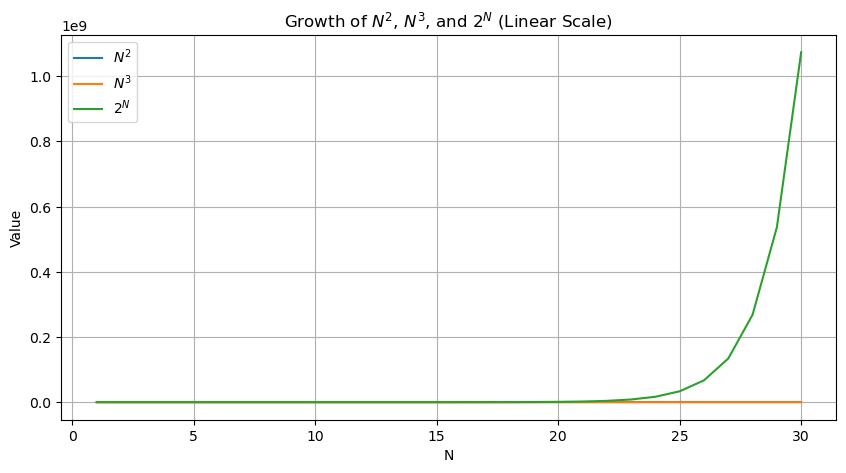

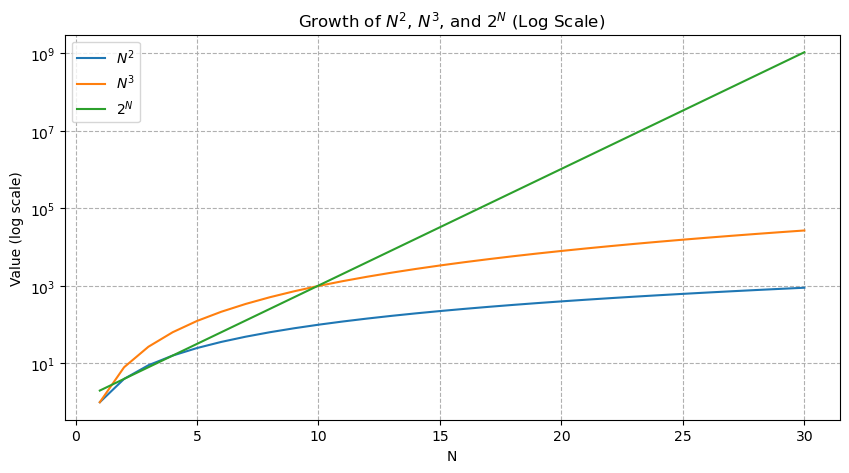

In [1]:
## 계산복잡도 체감
import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 준비
N = np.arange(1, 31)
N2 = N**2
N3 = N**3
expN = 2**N

# 2) 일반 축(Linear scale) 그래프
plt.figure(figsize=(10, 5))
plt.plot(N, N2, label=r"$N^2$")
plt.plot(N, N3, label=r"$N^3$")
plt.plot(N, expN, label=r"$2^N$")
plt.title("Growth of $N^2$, $N^3$, and $2^N$ (Linear Scale)")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# 3) 로그 축(Log scale) 그래프
plt.figure(figsize=(10, 5))
plt.plot(N, N2, label=r"$N^2$")
plt.plot(N, N3, label=r"$N^3$")
plt.plot(N, expN, label=r"$2^N$")
plt.yscale("log")
plt.title("Growth of $N^2$, $N^3$, and $2^N$ (Log Scale)")
plt.xlabel("N")
plt.ylabel("Value (log scale)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

N을 입력 크기라고 했을 때, $2^N$이 증가하는 속도가 $N^2, N^3$에 비해 압도적으로 빠른 것을 보실 수 있습니다. 로그 스케일이 아니면 비교 조차 힘들죠. 그래서 컴퓨터 과학에서는 계산복잡도가 입력 크기의 다항식으로 표현될 수 있는, 그래서 '좀 기다리면 결과를 얻을 수 있는' 알고리즘을 고안하는 것이 매우 중요한 주제입니다. 그리고 지금 우리가 마주한 커뮤니티 탐지 문제도, 바로 그런 알고리즘이 필요합니다. 

### 2.2. Hierarchical clustering을 활용한 접근과 커뮤니티 타당성 계량 문제

그래서 떠올려 볼 수 있는 대안적인 전략 중 하나가 위계적 클러스터링 알고리즘 (hierarchical clustering algorithm)을 활용한 접근입니다. 커뮤니티 탐지 역시 근본적으로는 클러스터링의 일종이라고 할 수 있습니다. 특정한 유사성이나 관련성의 논리를 가지고 노드들을 뭉쳐주는 일이라고 볼 수 있으니까요. 그래서 위계적 클러스터링 알고리즘을 쓸 수 있습니다. 

위계적 클러스터링 알고리즘을 간단히 설명하면 다음과 같습니다. 두 가지 버전이 있는데, 상향식이 이해가 편하니 그쪽을 먼저 생각해봅시다. 우선 개별 요소를 각각 개별적인 클러스터로 설정합니다. 그리고 클러스터 사이의 유사성을 측정하는 방법을 설정합니다. 전체 집합 안에 존재하는 클러스터 쌍들의 유사성을 측정합니다. 그 중 가장 유사한 클러스터 두 개를 합칩니다. 그런 다음 새로 병합되어 만들어진 클러스터와 나머지 클러스터 사이의 거리를 계산합니다. 그 결과 병합된 클러스터를 포함한 모든 클러스터 사이의 유사성 점수를 다시 얻을 수 있습니다. 이번에도 다시 가장 유사성이 큰 클러스터를 병합합니다. 그리고 위에 설명한 과정을 반복합니다. 즉 가장 유사한 요소들을 우선적으로 합쳐간다는 말입니다. 이것을 반복하면, 최종적으로 모든 데이터 포인트를 포함하는 하나의 클러스터가 만들어질 것입니다. 그리고 이 병합되는 과정을 기록하면 dendrogram을 얻을 수 있습니다. dendrogram의 예시는 아래와 같습니다. 

<div style="text-align:center;">
    <img src="_static/figures/덴드로그램 예시.jpg" width="300">
</div>

그런데 이 덴드로그램을 중간에 적당한 지점에서 절단하면 어떻게 될까요? 위 그림에서 빨간 점선처럼 절단한다고 하죠. 그러면, '유사성 관계가 반영된 상태에서 클러스터를 분할하는' 효과를 얻을 수 있습니다. 저기서 자른다면, G,H,I,J가 한 집합, C,A,B가 한 집합, 그리고 나머지가 한 집합을 형성하는 형태로 분할이 가능하죠. 즉 세 개의 클러스터가 생기는 것입니다. 

이처럼 위계적 클러스터링 알고리즘은 개별 요소를 유사성의 관점에서 위계적으로 묶어 나가는 덴드로그램을 만들고, 그 구조 정보를 반영하여 요소들의 유의미한 집합을 만듭니다. 어디서 끊을지는 분석자가 결정하는 것인데, 어디서 끊어내든 요소들의 유사성 관계를 반영한 결과가 나오죠. 그래서 보통 분석자가 미리 클러스터 개수를 정하거나 각 집합이 가지는 분산의 최대값 등을 설정해 둔 채 어디서 끊어낼지 정하곤 합니다. 

네트워크에 이걸 적용할 수 있습니다. 적용하지 못할 이유가 없습니다. 노드들 사이의 혹은 노드집합들 사이의 유사성 혹은 거리를 측정할 수만 있으면 이 같은 과정을 바로 적용할 수 있지요. 그 유사성 혹은 거리 개념이 네트워크 커뮤니티 속성을 반영할 수만 있으면, 즉 유사성이 높을 수록 같은 커뮤니티에 속할 가능성이 높다는 점만 보장할 수 있으면 됩니다. Ravasz 등이 제안한 알고리즘이 이런 방법을 택했습니다. 그들의 노드 간 유사성 지표는 다음과 같습니다. 이걸로 노드쌍 사이의 유사성을 측정하고, 가까운 것부터 묶어 나가는거죠. 

$$
X_{i,j} = \frac{J_{i,j}}{min(K_i, K_j)+1-\theta(A_{i,j})}
$$

$J_{i,j}$는 i와 j의 공통 이웃 숫자이고, $\theta(A_{i,j})$는 연결되어 있으면 1 아니면 0으로 만드는 함수라고 보시면 됩니다. 바라바시 책에 있는 그림을 보시면 실제 네트워크에 적용 사례를 이해하실 수 있으실 겁니다. (https://networksciencebook.com/chapter/9#hierarchical)

왜 이런 접근은 앞선 간단한 접근보다 실행 가능성 면에서 더 나을까요? 핵심은 위계적 클러스터링 알고리즘이 일종의 탐욕적 알고리즘 (greedy algorithm) 이라는 점에 있습니다. 탐욕적 알고리즘이란, 어떤 상태를 변형시켜 결과를 최적화하는 과정에서 결과가 개선되는 방향으로만 상태를 변형시키는 알고리즘을 말합니다. 예를 들어 지금 노드를 병합할 때 가장 거리가 가까운 노드쌍만을 합쳐나갔습니다. 주어진 상태에서 상태를 개선시키는 (이 경우에는 그럴듯한 커뮤니티로 이어지는) 가장 좋은 방법을 반복적으로 택한 셈입니다. 이런 탐욕적 알고리즘은 때로는 손실을 감수해야 더 좋은 상태로 나아갈 수 있다는 점을 간과한다는 점에서 항상 최적의 결과를 얻을 수는 없습니다. 하지만 논리가 단순하고 고려하는 상태의 숫자가 적기에 계산 부담이 적다는 장점이 있습니다. 사실 앞서 설명한 간단한 접근(모든 2분할 중 양 집단 사이 링크 적은 분할 고르기)은, 우리가 떠올리기 간단할 뿐 꽤나 빡샌 접근입니다. 모든 분할을 고려하고 그 중에서 가장 좋은 것을 고르겠다는 말이니까요. 즉 모든 상태 조합을 고려하겠다는 말입니다. 반면 위계적 클러스터링 알고리즘을 활용한 노드 병합은 모든 상태 조합을 고려하지 않습니다. 그때그때 가장 좋아보이는 병합을 반복하여 최종적으로 하나의 집합이 되면 작업을 종료합니다. 그래서 계산량이 상대적으로 적지요. 앞서 아주 간단한 2분할 조차 계산 복잡도가 $O(2^N)$ 이었는데, 위계적 클러스터링 알고리즘을 쓰면 전형적인 구현 방식에서는 $O(N^3)$으로 줄어듭니다. 방식에 따라 더 낮아질 수도 있습니다. 즉 실행가능한 수준이 됩니다. 

네트워크 커뮤니티 탐지에서 잘 알려진 Girvan–Newman 알고리즘은 위계적 클러스터링의 하향식(divisive) 접근 사례입니다. 이 방법은 유사한 노드를 묶어가는 대신, 전체 네트워크를 하나의 클러스터로 두고 시작해, 점차 나누어가는 방식으로 작동합니다. 어떤 링크를 먼저 끊을지 결정하기 위해, 이들은 link betweenness centrality가 가장 큰 링크부터 제거했습니다. link betweenness centrality는 앞선 시간 우리가 살펴본 betweenness centrality를 링크 수준에서 계산한 것입니다. '노드 쌍 사이의 최단 경로에 어떤 링크가 포함되는 횟수'로 정의하면, 링크 수준에서도 충분히 계산 가능합니다. 그리고 노드가 그랬듯이, betweenness centrality가 큰 링크는 서로 다른 집단 사이를 연결하는 다리 역할을 하는 경우가 많고, 그래서 끊을 가치가 있습니다. 이런 방식으로 링크를 순차적으로 제거해 나가면 최종적으로는 모든 노드가 분리되고, 이 과정을 거꾸로 쌓아가면 dendrogram을 얻을 수 있습니다.

이렇게 상향식이든 하향식이든, 노드들을 가지고 덴드로그램을 만들고 나면, 그 다음에는 적당한 곳에서 끊어내면 끝입니다. 그러면 네트워크 커뮤니티 구조를 얻을 수 있는 거죠. 그런데 여기서 또 하나의 중요한 문제를 마주합니다. *적당한 곳에서 끊는다*는게 대체 뭘까요. 이 적당한 위치는 어떻게 정할 수 있을까요?

앞서 통상적으로 미리 클러스터의 개수를 정하고 들어올 수 있다고 말씀드렸습니다. 마찬가지로 네트워크 커뮤니티 개수를 미리 설정하고 들어오면 여기서 고민없이 끊을 곳을 정할 수 있지요. 그런데 그건 보통 적절치 않은 방법입니다. 우리는 커뮤니티 구조를 잘 몰라서 이 작업을 합니다. 미리 개수만 미리 알고 있는 경우는 별로 없죠. 예를 들어 어떤 언어 자료를 분석하는데 거기에 존재하는 주제 개수를 미리 아는 경우가 얼마나 될까요? 그래서 개수를 미리 정하고 접근할 수는 없습니다. 

가장 정석적인 방법은 '여기서 끊으면 커뮤니티 구조가 가장 그럴 듯하다'고 판단할 수 있는 근거를 제시하는 것입니다. 그리고 그것을 하기 위해서는 어떤 잠정적인 네트워크 커뮤니티 구조의 타당성을 계량할 수 있는 점수가 필요합니다. 그 점수에 근거하여, '여기서 끊는 것보다 저기서 끊는게 더 낫다'고 판단할 수 있는거죠. 즉 '네트워크 커뮤니티 구조 타당성 지표'가 우리에게 필요합니다. 

앞서 기본적인 접근법으로 살펴본 네트워크 2분할 기법에서 '커뮤니티 사이에 존재하는 링크수'도 일종의 이런 타당성 지표라고 할 수 있을 것입니다. 하지만 이건 사용할 수가 없죠. 왜냐하면, 이 지표는 커뮤니티 숫자가 줄어들면, 즉 노드 클러스터를 줄이기만 하면 무조건 개선되니까요. 덴드로그램의 분할 위치는 클러스터 개수까지 결정하는 과정이므로, 이런 지표를 써서는 그냥 무조건 모두 합치는 방향으로 가게 될 것입니다. 사실 이런 지표는 커뮤니티 숫자가 미리 정해져있고 그 안에서 변형을 가할 때에나 적용 가능하죠. 지금 사용할 수는 없습니다. 

이것이 바로 제가 앞에서 언급한 두 번째 핵심 문제, **커뮤니티 구조 타당성을 계량하는 문제**입니다. 

커뮤니티 탐지 절차는 이 두 가지 문제를 어떻게든 해결해야 합니다. 즉 계산 복잡도를 한정한 상태에서, 나름의 타당성 지표를 동원하여 커뮤니티를 포착해야 합니다. 실제로 활용되는 알고리즘들은 모두 이를 나름의 방식으로 다루면서 극복하려고 합니다. 그리고 우리가 데이터나 상황에 따라 적합하게 커뮤니티 탐지 알고리즘을 선택하기 위해서는 각 알고리즘들이 이를 어떻게 해내는지 이해할 필요가 있습니다. 그래야 데이터에 적합한 형태로 네트워크 구조를 탐지하고, 그 결과를 해석할 수 있기 때문입니다. 그래서 우선 우리는 두 번째 문제, 커뮤니티 구조 타당성 계량 문제를 다루는 방법 부터 알아볼 것입니다. 왜냐하면 그게 일단 설정되어야, 이 지표를 계산하고 최적화하는 과정에서 계산 복잡도를 한정하는 문제도 이어서 풀 수 있기 때문입니다. 이를 위해 '모듈도'(modularity)라는 전통적인 지표부터 알아보겠습니다. 

## 3. 모듈도 (modularity) 와 커뮤니티 구조의 타당성

### 3.1. 모듈도의 개념과 의도

Modularity, 한국어로 모듈도로 번역하는 이 개념은 네트워크 커뮤니티에서 매우 중요한 위치를 차지하고 있습니다. 이는 우리가 만들어낸 네트워크 분할이 얼마나 잘 '커뮤니티 구조'를 드러내는지 측정하는 개념입니다. 앞서 말한 네트워크 구조의 타당성 정도를 표현하는 수치인 것이지요. 이걸 왜 모듈도라고 부르는지는, 모듈(module)이라는 말이 의미하는 바를 떠올려보면 이해할 수 있습니다. 모듈이란 다양한 분야에서 자율성을 갖춘 부분 시스템을 가리킬 때 사용하는 단어인데요, 전체 시스템은 이런 모듈의 연결을 통해 작동합니다. 그리고 모듈 내부는 강하게 결합 및 응집되어 있지요. 그렇기에 네트워크 과학에서 모듈도는 우리가 가정한 커뮤니티 구조가 (즉 노드별 커뮤니티 레이블) 얼마나 모듈에 부합하는지, 그래서 전체 시스템에서 모듈과 유사한 부분 시스템 (부분 그래프)를 얼마나 잘 찾아냈는지 측정하는 개념이 됩니다. 

한 가지 주의할 점은, **이 모듈도는 네트워크 자체만 있다고 계산되는 것이 아니라, 우리가 부여한 커뮤니티 구조 (즉 노드 1은 몇 번 커뮤니티, 2는 몇 번 커뮤니티....등등)와 네트워크가 결합되어 계산된다는 점**입니다. 그렇기에 모듈도는 우리가 만들어낸 네트워크 커뮤니티 구조의 타당도 혹은 완성도를 표현하는 지표가 됩니다. 그렇기에 앞서 말한 위계적 클러스터링 알고리즘이 만들어낸 dendrogram에서 어디를 절단하면 될지 알려주는 도구가 될 수 있습니다. 왜냐하면 여러 절단 가능성과 그에 따라 형성되는 커뮤니티 구조 중에서 가장 modularity가 높은 포인트에서 절단하는 선택이 가능해지거든요. 덴드로그램을 절단할 수 있는 가능성의 가짓수는 전체 네트워크를 절단하는 숫자에 비해서는 매우매우 작습니다. 그러니 효율성도 함께 확보할 수 있는 겁니다. 

구체적으로 modularity 수치는 어떻게 정의되고, 왜 그렇게 정의하는 것일까요? 일단 정의는 이러합니다. 

$$
Q = \frac{1}{2m}\sum_{c=1}^C\sum_{(i,j)\in C_{c}}\big(A_{i,j} - \frac{K_{i} \cdot K_{j}}{2m}\big)
$$

이 표현은 기본적으로 **우리가 설정한 커뮤니티 내부의 링크 숫자가 무작위 네트워크 (random network)에서 기대할 수 있는 링크 숫자보다 얼마나 많은지를 계량화하는 표현**입니다. 시그마 맨 안쪽을 보면, 해당 커뮤니티에 속하는 링크를 순회하며 $A_{i,j}$의 값에서 $\frac{K_i \cdot K_j}{2m}$을 빼서 모두 더한다고 되어 있습니다. 우선 $A_{i,j}$는 해당 커뮤니티에 있는 링크의 숫자를 표현하게 됩니다. A가 adjacency matrix이니 당연합니다. (i, j)는 노드쌍을 가리키는데, $(i,j)\in C_{c}$ 파트는 '특정 커뮤니티 안에 있는 노드쌍'으로 한정하고 있기 때문입니다. 그러니 $A_{i,j}$를 다 더하면 특정 커뮤니티 안에 있는 링크 숫자가 되죠 (링크가 있으면 1, 없으면 0으로 되어 있다고 가정합시다).  $\frac{K_i \cdot K_j}{2m}$ 는 i번째 노드와 j번째 노드 사이에 존재할 수 있는 링크의 기대값입니다. **여기서 이 기대값이 무작위 네트워크라는 가정 하에서 만들어진다는 점이 중요합니다.**  

왜 기대값이 이렇게 설정될까요? 우선 $K_i K_j$는 각각 i의 degree와 j의 degree를 의미합니다. 즉 각 노드의 링크수이지요. 그리고 i와 j가 무작위 네트워크 하에서 연결되는 상황을 상상해봅시다. 즉 i와 j가 우연히 연결되는 상황 말입니다. i번째 노드가 임의의 노드를 향해 손을 뻗습니다. 그 중 j의 손이 잡히면, i와 j가 연결되는 것이지요. 그런데 수 많은 노드 중 j의 손을 잡을 확률은 얼마인가요? 무작위 네트워크 상황에서 말입니다. 

그 확률은 $\frac{K_j}{2m}$으로 표현이 가능합니다. m은 네트워크 안에 존재하는 총 링크의 숫자입니다. 그런데 모든 노드의 degree, 즉 링크수를 다 더하면 딱 이 총 링크 갯수의 2배가 나옵니다. 왜냐하면 하나의 링크가 있다면, 그것은 두 노드의 degree, 링크수에 기여하기 때문입니다. 그러면 $\frac{K_j}{2m}$은 모든 노드의 degree의 합에서 j 노드가 차지하는 비율이 됩니다. 그런데, 그게 i가 무작위로 손을 뻗었을 때 j가 그 손을 잡는 확률이라고 해석할 수 있습니다. 

조금 직관적으로 생각해보자면, 각 노드가 특정한 디그리를 갖고 서로 악수를 하려고 달려드는 문어라고 상상해봅시다. 아래 그림처럼 말이지요. 그리고 무작위로 이렇게 손을 뻗다가 서로 손이 잡히면 그 둘 사이에 링크가 형성되는 것입니다. 그게 무작위 네트워크라고 할 수 있을 것입니다. 그런데 i 입장에서는 맞잡을 손의 총 숫자가 2m개인데, 그 중 j의 손은 $K_j$개인 셈이지요. 그렇기 때문에 무작위로 손을 뻗을 때 j가 잡힐 확률이 $\frac{K_j}{2m}$ 라고 표현할 수 있는 것입니다. 

여기서 시도 횟수 개념이 한 번 더 들어갑니다. i는 한 번만 시도를 하는 것이 아닙니다. 자신의 degree만큼 시도를 하겠지요. 그래서 $\frac{K_i \cdot K_j}{2m}$ 가 됩니다. 즉, 시도 횟수 곱하기 확률인 셈이지요. 다시 말하지만, 이것은 '무작위 네트워크 가정 하에서 i와 j사이에 링크가 있을 확률'입니다. 그렇기에 $A_{i,j} - \frac{K_i \cdot K_j}{2m}$를 특정 커뮤니티 (우리가 설정한) 안에서 다 합치면, **해당 커뮤니티 안에 실제로 있는 링크수에서 무작위 네트워크 하에서 해당 노드들 사이에 있을 법한 링크의 숫자를 뺀 값**이 되는 것입니다. 

<div style="text-align:center;">
    <img src="_static/figures/문어 두 마리.jpg" width="400">
</div>

그래서 Modularity는 위에서 설명한 '우리가 설정한 커뮤니티 내부 링크의 실제값 - 무작위 네트워크 하에서 기대값' 작업을 전체 네트워크에서 하고, 그걸 전체 링크 숫자로 나눠서 표준화해 준 값이라 할 수 있습니다. 그 네트워크에 링크가 많으면 아무래도 실제값과 기대값의 차이도 자연히 커질 수 있으니 그 규모 효과를 제거하는 거죠. 

그런데 왜 이런 방식으로 지표를 잡는 것일까요? 그것은 근본적으로 **무작위 네트워크에서는 우리가 앞에서 정의한 의미의 커뮤니티 구조가 체계적으로 나타나기 어렵다**는 가정 때문입니다. 앞서 커뮤니티는 상대적으로 그 안에서 링크가 많이 형성되는 노드 집합이라고 말했습니다. 왜 커뮤니티가 생겼을까요? 그건 그 네트워크가 표현하고 있는 시스템 안에, 그렇게 되어야 할 어떤 이유가 있기 때문일 것입니다. 예를 들어 앞서 말했던 가라데 클럽 네트워크에서 커뮤니티는, 경쟁하는 두 파벌 때문에 생겼습니다. 아무래도 서로 친하고 긴밀한 파벌 안에서 링크가 형성될 가능성이 더 클테니, 자연스럽게 네트워크 구조가 생기는거죠. 토큰 네트워크 역시 마찬가지입니다. 글을 작성하는 사람들이 가진 '주제'라는 것이 있고, 그 주제를 전달하기 위해 특정 토큰 들 사이의 연결이 (동시 출현 혹은 근접 출현) 더 긴밀해지는 것이지요. 

이처럼 시스템에 존재하는 어떤 잠재 변수의 작동은, 그 시스템을 표현하는 네트워크가 '무작위 네트워크'가 아님을 의미합니다. 즉 노드들이 아무 노드들과 연결되는 것이 아니라, 부분 모듈의 기능을 수행하기 위해 '분명한 이유를 가지고', '특정한 노드 집합'과 연결됩니다. 그러면 커뮤니티 구조를 강하게 만드는 요인이 두드러질 수록, 그 네트워크는 무작위 네트워크와 거리가 멀어질 수 밖에 없습니다. 아무나 연결되는 구조는 커뮤니티 구조와는 거리가 멀다는 말입니다. 그렇기에 거꾸로 무작위 네트워크와의 거리를 통해서 우리가 가정한 커뮤니티 구조가 얼마나 그럴 듯한지를 측정할 수도 있는 것이지요. 

통계를 좋아하시는 분들이라면 이 설명이 더 와닿을 수도 있겠네요. 무작위 네트워크는 커뮤니티는 존재하지 않는다는 귀무가설 하의 네트워크 모습입니다. 그리고 우리가 설정한 커뮤니티 내부의 링크수와 기대값의 차이, 즉 모듈러리티는 커뮤니티 구조의 존재를 암시하는 일종의 검정 통계량 같은 것이고요. 우리는 이 검정통계량이 크면 클수록 귀무가설 세계와 나의 네트워크가 크게 차이가 난다고, 그래서 커뮤니티 구조가 분명 존재하고 우리가 제법 잘 포착했다고 생각할 수 있을 것입니다. 

### 3.2. 모듈도의 활용과 해상도 문제

자 이제 우리에게는 모듈도(modularity)가 있습니다. 우리가 잠정적으로 설정한 네트워크 커뮤니티 구조의 타당성 정도를 계량할 지표가 생긴 것이지요. 덕분에 앞서 위계적 클러스터링 알고리즘을 활용한 네트워크 커뮤니티 탐지 알고리즘을 완결할 수 있습니다. ‘어디서 절단할 것인가?’가 문제였는데, 각 절단 결과 주어지는 모듈도 크기를 비교하면, 어디서 절단할지 결정할 수 있습니다. 

아예 모듈도를 직접적으로 활용하는 다른 탐욕 알고리즘 (greedy algorithm)을 설계해 볼 수도 있을 것입니다. 예를 들어 아래와 같은 식인거죠. 

1) 모든 노드들에 개별 커뮤니티 부여 
2) 두 커뮤니티를 합쳤을 때 modularity 변화량 계산 (둘 사이의 링크가 있는 전체 커뮤니티 쌍을 대상으로)
3) 가장 Modularity 변화가 큰 커뮤니티 쌍을 합쳐 상위 커뮤니티로 형성 
4) 이 과정을 Modularity가 더 이상 증가하는 병합이 없을 때까지 반복

이건 greedy modularity maximization 알고리즘 중 가장 기본적인 형태입니다. Networkx에도 구현되어 있습니다. 위계적 클러스터링 알고리즘을 활용한 접근에서는 병합 혹은 분할은 나름의 기준으로 하면서 덴드로그램을 만들고 절단 지점을 결정할 때만 모듈도를 활용한 셈이지만, 이런 알고리즘은 아예 병합 과정 자체에서 모듈도를 활용하는 것이지요. 여담입니다만, 이런 기본적인 알고리즘을 변형하여 실제로 많이 활용되는 루뱅 알고리즘 등이 만들어집니다. 

자 그러면 모든 문제가 해결되었을까요? 그렇게 보기는 어렵습니다. 일단 가장 간단하게는 탐욕 알고리즘이 가진 문제가 여전히 남아있습니다. 위계적 클러스터링을 활용하는 경우와 greedy modularity maximization 알고리즘은 모두 탐욕 알고리즘의 일종입니다. 그러다보니 일종의 ‘전역최적해’, 그러니까 ‘가장 우수한 정답’을 찾는다는 보장이 없습니다. 즉 ‘가장 그럴 듯한 네트워크 커뮤니티 구조’를 ‘모듈도가 가장 높은 네트워크 커뮤니티 구조’를 찾을 수 있다는 보장이 없다는 말입니다. 

그런데 이건 사실 모든 탐욕 알고리즘이 가진 문제입니다. 그리고 네트워크 커뮤니티 탐지 문제처럼 정답 가능성의 공간이 매우 넓을 때, 그러니까 해답이 가질 수 있는 형태의 가능성이 너무 다양할 때, 전역최적해를 찾아내는 알고리즘은 오히려 드뭅니다. 탐색해야 하는 공간이 넓으면 넓을수록 우리는 타협을 하곤 합니다. 최적화라는 파트가 이런 타협을 다루지요. 그리고 이건 모듈도와는 상관없는, 즉 모듈도 때문에 생긴 문제가 아닙니다. 모듈도가 높은 해답을 찾아내는 검색 효율의 문제이죠. 

그런데 더 결정적인 문제는 **모듈도 자체가 약점이 있다**는 점입니다. 이는 모듈도를 기준으로 삼아 운용하는 방법의 효율성보다 더 근본적인 문제가 될 수 있습니다. 지표 자체가 약점이 있다는 뜻이니까요. 가장 대표적인 문제가 **해상도 문제 (resolution problem)** 입니다. 

해상도 문제는 모듈도(modularity)를 기준으로 삼은 커뮤니티 탐지 작업 절차, 즉 알고리즘으로는 전체 네트워크에서 상대적으로 작은 규모의 커뮤니티를 찾아내기 어렵다는 말입니다. 해상도라는 말은 주로 모니터 같은 시각 표현 기계에 많이 쓰입니다. 모니터 해상도가 높다고 하면, 그건 모니터 전체를 매우 작은 사각형으로 갈라서 일일이 색을 표현하고 있다는 뜻입니다. 예를 들어 FHD면, 1920X1080로 전체 모니터를 잘개 쪼개어서 각 점마다 색을 쏴주고 있는거죠. 이 점들이 많으면 많을수록 이미지가 자연스러워집니다. 그렇기에 해상도가 높다는 말은 '작은 실체를 구분해서 잘 포착한다'는 말이 될 수도 있습니다. 이걸 네트워크 커뮤니티 탐지에 적용하면, '작은 커뮤니티도 잘 포착한다'가 되는데, 모듈도라는 지표는 이걸 해내는데 구조적인 한계를 가집니다. 

<div style="text-align:center;">
    <img src="_static/figures/해상도예시.jpg" width="300">
</div>

왜 그럴까요? 규모가 작은 커뮤니티를 합쳤을 때, 즉 합쳐서는 안될 커뮤니티를 합쳐버렸을 때 모듈도가 어떻게 변동하는지 살펴보면 이해가 됩니다. 그런데 그걸 위해서는 모듈도를 직접 계산해 보는게 좋은데, 커뮤니티를 합쳤을 때 모듈도 변동을 쉽게 알아보기 위해 우리가 앞서 살펴본 공식을 약간 변형해보겠습니다. 앞서 우리가 본 공식은 이렇습니다. 

$$
Q = \frac{1}{2m}\sum_{c=1}^C\sum_{(i,j)\in C_{c}}\big(A_{i,j} - \frac{K_{i} \cdot K_{j}}{2m}\big)
$$

이걸 이렇게 바꿀 수 있습니다. $m_c$는 커뮤니티 안의 링크수 (커뮤니티 사이의 링크는 제외합니다) $K_c$는 커뮤니티에 속한 노드의 총 디그리 합입니다. 

$$
Q = \sum_{c=1}^C \big(\frac{m_c}{m} - (\frac{K_c}{2m})^2\big)
$$

이렇게 바꿀 수 있는 이유는 사실 간단한데, 원 수식으로부터 두 번째 수식으로 가는 과정을 간단히 전개해보겠습니다.


$$
\begin{aligned}
Q &= \frac{1}{2m}\sum_{c=1}^C\sum_{(i,j)\in C_{c}}\big(A_{i,j} - \frac{K_{i} \cdot K_{j}}{2m}\big) \\[15pt]
&= \frac{1}{2m}\sum_{c=1}^C\sum_{(i,j)\in C_{c}} A_{i,j} - \frac{1}{2m}\sum_{c=1}^C\sum_{(i,j)\in C_{c}}\frac{K_{i} \cdot K_{j}}{2m} \\[15pt]
&= \frac{1}{2m}\sum_{c=1}^C 2m_c - \frac{1}{2m}\sum_{c=1}^C \frac{K_c^2}{2m}\\[15pt]
&= \sum_{c=1}^C \big(\frac{m_c}{m} - (\frac{K_c}{2m})^2\big)
\end{aligned}
$$


즉 시그마를 구성하는 두 항을 분리해서 정리하면 아래와 같이 됩니다. 유일하게 직관적으로 이해가 안가실 수 있는 부분은 $K_i \cdot K_j$가 $K_c^2$이 되는 부분이실것 같습니다. 이건 $K_i$가 i의 디그리라는 뜻이고, 그걸 특정 커뮤니티 $C_c$에 속한 모든 노드에 대해서 다 더하게 되면, 결국 그 커뮤니티에 존재하는 모든 노드의 디그리를 다 합친 값, 즉 $K_c$가 된다는 점만 떠올리시면 됩니다. 그리고 그건, $K_j$도 마찬가지이니, 둘 다 $K_c$가 되는 것이고, 둘을 곱하니까 $K_c^2$이 된 거죠. 

자 그럼 이 공식을 염두에 두고 아래의 상황을 상상해봅시다. 마크 뉴먼의 책(*Networks*)에 있는 그림을 재구성한 것인데요, 어떠신가요? 이 상황을 대강 설명드리면 일단 Group1과 Group2는 명백히 개별적인 커뮤니티를 형성하고 있습니다. 내부에는 링크가 조밀하고, 둘 사이에는 링크가 딱 하나 있습니다. 그런데 나머지 네트워크 부분이 굉장히 큽니다. 아래에 회색 노드로 표현된 부분이 그렇죠. 제가 강조하려고 Group1과 Group2의 노드 크기를 좀 키워서 표현했는데, 다 동일 크기로 맞췄다고 상상해보시면, 나머지 부분이 압도적으로 큼을 쉽게 짐작하실 수 있을 것입니다. 

자 이 상황에서, 커뮤니티 탐지 알고리즘이 제대로 작동한다면, 저 둘은 따로 커뮤니티가 부여되어야 합니다. 솔직히 저런거 따로 잡아내라고 알고리즘을 쓰는거죠. 그리고 만약 모듈도에 근거한 알고리즘이 그런 방식으로 작동하려면, Group1과 Group2를 합쳤을 때 모듈도가 감소해야 합니다. 그래야 알고리즘이 이 둘을 분리하는 방향으로 움직이겠죠. 

<div style="text-align:center;">
    <img src="_static/figures/resolution_limit_network.jpg" width="400">
</div>

그런데 문제는 조건에 따라, 저처럼 명백한 상황임에도 불구하고, Group1과 Group2를 합치면 모듈도가 증가하는 일이 생길 수 있다는 점입니다. 저 둘이 합쳐질 때 모듈도는 어떻게 변화할까요? 앞서 정리한 공식을 이용해봅시다. 계산을 편하게 하기 위해 Group1과 Group2가 합쳐졌을 때 그 거대 커뮤니티의 내부 링크수와 거기에 속한 모든 노드의 총 디그리 합을 먼저 정의해둡시다. 그건 다음과 같습니다. 

$$
\begin{aligned}
m_{A \cup B} &= m_A + m_B+ m_{AB} \\
K_{A \cup B} &= K_A + K_B
\end{aligned}
$$

즉 합쳐진 커뮤니티 내부 링크 숫자는 원래 각 커뮤니티(Group1, Group2) 링크 숫자 더하기 둘 사이를 잇는 링크 숫자이고, 커뮤니티 소속 노드 디그리 총 합은 그냥 합친게 되는거죠. 그럼 둘을 합치면 모듈도가 어떻게 변동할까요? 그건 위에서 우리가 변형한 공식을 활용해서 이렇게 써질 것입니다. 

$$
\begin{aligned}
\Delta Q = \big(\frac{m_{A \cup B}}{m} - (\frac{K_{A \cup B}}{2m})^2\big) - \big(\frac{m_A}{m} - (\frac{K_A}{2m})^2 + \frac{m_B}{m} - (\frac{K_B}{2m})^2 \big)
\end{aligned}
$$

이걸 정리하면 아래처럼 표현됩니다. 

$$
\frac{m_{AB}}{m} - \frac{K_A \cdot K_B}{2m^2}
$$

그런데 이 수치가 상황에 따라서 0보다 클 수 있습니다. 위의 이미지의 경우 $m_{AB}$가 1입니다. 즉 두 그룹 사이의 링크가 하나 밖에 없죠. 그런 극단적 상황에서도 $\frac{1}{m} - \frac{K_A \cdot K_B}{2m^2} > 0 $ 이기만 하면, 정리해보면 $2m > K_A \cdot K_B $ 이기만 하면 $\Delta Q$가, 그러니까 모듈도 변화량이 0보다 커집니다! 합치면 모듈도가 올라간다는 말입니다! 그러면 모듈도를 기준으로 삼는 알고리즘들은 이 두 노드 집합을 합쳐서 커뮤니티 구조를 포착할 것입니다. 왜냐하면 그래야 모듈도가 커지니까요. 우리에겐 상당히 좋지 않은 상황입니다. 

이런 좋지 않은 상황, 그러니까 $2m > K_A \cdot K_B $가 되는 상황은 구체적으로 어떤 상황일까요? m, 그러니까 전체 링크수가 무척 많고 (즉 전체 네트워크가 무척 크고 / 지금 예시와 같은 상황이죠), $K_A \cdot K_B$이 그 보다 작은 상황입니다. $K_A \cdot K_B$이 작으려면 $K_A, K_B$ 둘이 각각 작아야 하는데, 이건 Group1과 Group2의 규모가 작으면 쉽게 달성됩니다. 각 커뮤니티 소속 노드의 총 디그리는 거기에 속한 노드가 작으면 자연히 작아지니까요. 그러면 이 조건이 가리키는 상황은, **'이론적으로 명확히 구분되는 커뮤니티가 나머지 네트워크에 비해 상대적으로 매우 작은 규모인 상황'** 이라고 할 수 있습니다. 그런 경우에는 분명 구분되는 커뮤니티가 합쳐졌을 때 오히려 모듈도가 올라갈 수 있다는 것이지요. 이는 상대적으로 크기가 작은 커뮤니티를 포착하는 작업에서 문제가 될 수 있습니다. 그래서 이걸 해상도 문제 (resolution problem)라고 부르는 것입니다. 

## 4. 실제 활용되는 다양한 커뮤니티 포착 알고리즘

### 4.1. 실제 커뮤니티 포착 알고리즘과 두 가지 문제

이제까지 살펴본 내용을 요약하면 이렇습니다. 커뮤니티를 포착하면 여러모로 좋을 듯하여 그 탐지 방법에 대해 고민했습니다. 그러다보니 계산복잡도 문제를 만났습니다. 그래서 이를 적당히 한정하는 몇 가지 간단한 작업 절차, 알고리즘을 떠올렸습니다. 그러자 커뮤니티 구조의 타당성을 계량하는 지표의 필요성을 느낄 수 있었습니다. 모듈도는 이에 부응하는 전통적인 지표입니다. 하지만 안타깝게도 모듈도는 완벽한 지표라고 보기는 어려웠습니다. 해상도 문제 등을 포함하고 있지요. 

우리가 이 사고의 과정을 거친 까닭은 커뮤니티 탐지 작업이 마주할 수 밖에 없는 두 가지 문제 혹은 필요성을 생생하게 확인하기 위함이었습니다. 정리해보겠습니다. 

1) 커뮤니티 탐지는 계산 복잡도를 일정 수준으로 한정할 필요성이 있습니다. 여러 번 말했듯이 커뮤니티 구조는 가능성이 너무 많습니다. 100개의 노드만 주어져도 그것을 가지고 세부 집합을 형성하는 방법이 엄청나게 늘어납니다. 우리가 탐색해야 할 정답의 공간이 너무 넓다는 말입니다. 이걸 다 살펴보자고 덤비면 계산량을 감당할 수 없습니다. 즉 계산 복잡도를 한정한 상태에서 진행할 수 있는 작업 절차가 필요합니다. 보통 그것은 유력한 커뮤니티 구조 (즉 유력한 정답)을 우선적으로 효율적으로 검색하는 방식인 경우가 많죠. 

2) 커뮤니티 구조 타당성을 적절히 계량할 방법을 마련할 필요성이 있습니다. 여러 커뮤니티 구조를 고려하면서 결론을 내기 위해서는 판단 기준이 필요합니다. 1안과 2안 중에 뭐가 더 나은 커뮤니티 구조안인지를 알 수 있어야 합니다. 모듈도는 그를 위한 가장 전통적인 지표입니다. 하지만 이 지표가 가진 문제점도 이미 잘 알려져 있습니다. 그렇기에 실제 작업에서는 이 단점을 보완할 방법을 마련하거나 다른 접근법을 떠올리려고 하는 경우가 많습니다. 

물론 이것말고도 문제가 있을 수 있습니다. 해(solution)의 안정성이라거나 중첩 커뮤니티 포착이라거나 시간에 따라 변해가는 커뮤니티를 포착하는 방법 등이죠. 하지만 이들은 특정한 상황을 가정한 경우가 많습니다. 그래서 제 생각에 커뮤니티 탐지라는 작업이 가장 보편적으로 다루게 되는 문제는 이 두 가지 아닐까 싶습니다.

실제로 우리가 활용하는 다양한 커뮤니티 포착 알고리즘은 어떤 형태로든 이 두 가지 문제 혹은 필요성을 다루고 있습니다. 물론 둘 모두를 정말이지 완벽하게 해결했다고 할 만한 방법은 없습니다. 하지만 그 점이 커뮤니티 탐지 알고리즘들의 가치를 떨어트리지는 않습니다. 인생도 그렇지만, 완벽한 해결책이란 없는 경우가 훨씬 더 많죠. 대신 조건과 상황에 따라 적절하다고 판단할 만한, 적어도 특정 상황에서는 유용성이 크다고 볼 수 있는 해결책이나 전략이 존재할 뿐입니다. 앞으로 우리가 살펴볼, 즉 실제 우리가 활용하는 커뮤니티 탐지 알고리즘은 이런 실질적인 목표에는 분명히 부합합니다. 그들은 이 두 가지 문제를 각기 다른 방식으로 타협하며 해결하려는 시도들이죠. 우리에게 필요한 것은, 각 알고리즘이 무엇을 목표로 무엇을 희생하는지, 그 과정에서 생기는 효과가 무엇인지를 분명히 알고 상황에 따라 적절히 사용할 수 있는 능력입니다. 

이를 위해 이 절에서는 대표적이고 실무에서도 많이 활용되는 커뮤니티 포착 알고리즘을 몇 가지 구체적으로 알아보고 그것의 장점과 단점을 생각해볼 것입니다. 이를 위해 포르투나토 선생님이 정리한 네트워크 커뮤니티 탐지 알고리즘의 범주를 활용하여(Fortunato, S., & Hric, D. (2016). Community detection in networks: A user guide. *Physics reports*, 659, 1-44.), 각 범주마다 하나씩 가져와보겠습니다. 그 범주와 각 범주에서 살펴볼 기법은 아래와 같습니다. 


1. 통계적 추론에 근거한 방법들(Methods based on statistical inference) -> 확률적 블럭 모델(Stochastic Block Model, SBM)을 활용한 커뮤니티 탐지
2. 최적화에 근거한 방법들(Methods based on optimization) -> 루뱅 (Louvain) 알고리즘
3. 동역학에 근거한 방법들(Methods based on dynamics) -> 워크트랩 (Walktrap) 알고리즘

설명 순서는 워크트랩 -> 루뱅 -> SBM 순으로 진행하겠습니다. 제 생각에 그게 이해가 편할거 같아서요^^ 미리 말씀드리자면, 워크트랩은 국소적 구조 판단을, 루뱅은 대규모 네트워크에서 효율성을, SBM은 통계 모델링 관점을 각각 강조하는 방법입니다. 하나하나 살펴보시면, 쉽게 이해가 가실겁니다. 




### 4.2. 워크트랩(Walktrap) 알고리즘

동역학에 근거한 방법들(Methods based on dynamics)의 한 사례로 워크트랩(Walktrap) 알고리즘을 설명하고자 합니다. 동역학에 근거한 방법들이라는 말이 가리키는 것은, 이 방법들이 네트워크 구조를 탐지할 때 네트워크에서 발생하는 흐름이나 움직임을 참조한다는 점입니다. 

워크트랩 알고리즘은 랜덤 워크(random walk)를 활용한 방법입니다. 일단 이 알고리즘은 네트워크의 각 노드에서 랜덤 워크(random walk)가 일어난다고 가정합니다. 즉 네트워크를 지도 같은거라고 생각하고, 각 노드를 출발점으로 삼고, 그 위에 주정뱅이^^ 같은 존재가 있어서, 무작위로 움직인다고 보는 것입니다. 움직일 수 있는 거리는 미리 통제해둡니다. (예를 들어 2번, 혹은 4번 이런식으로) 

그러면 각 노드의 입장에서 다른 노드들에 이르는 'random walk에 기반한 도달 확률'이 나옵니다. 예를 들어 특정 노드에서 어떤 노드는 랜덤 워크로 쉽게 닿을 수 있는데 다른 노드는 그렇지 않을 수 있지요. 그리고 짐작하듯이, 이건 네트워크 구조가 생긴 모양에 큰 영향을 받을 것입니다. 이렇게 특정 노드에서 다른 노드에 도달할 수 있는 확률을 얻는 과정을 모든 노드에 대해 반복하면, 모든 노드의 입장에서 나머지 노드들에 랜덤 워크를 활용해 닿을 수 있는 확률 분포들을 구할 수 있습니다. 

이렇게 구한 확률은 각 노드들이 다른 노드들과 가지는 '거리'라고 해석할 수 있습니다. 즉, 개별 노드들에서 나머지 노드들에 랜덤 워크로 도달할 확률이 크면 거리가 가깝다고 해석할 수 있습니다. 반대로 확률이 작으면 거리가 멀다고 해석할 수 있지요. 그러면 이 확률 분포에 근거하여 일종의 거리 행렬 (distance matrix)를 만들 수 있습니다. 즉 랜덤워크 거리라는 독특한 거리인 셈이지요. 

이런 노드들 사이의 거리 행렬이 존재하면, 이걸 가지고 위계적 클러스터링 알고리즘을 적용할 수 있습니다. 그러면 가까운 노드끼리 먼저 묶어주는 덴드로그램을 만들 수 있습니다. 그리고 앞서 본 것처럼 적절한 곳에서 끊어내면 노드들의 집합, 즉 커뮤니티 구조를 얻을 수 있습니다. 그리고 이 '적절한 곳'은 모듈도를 가지고 찾습니다. 

요컨대, 1) 랜덤 워크에 기반한 노드들 사이의 도달 확률 분포를 얻고, 2) 그걸 거리로 해석하고, 3) 그걸 위계적 클러스터링 알고리즘에 넣고, 4) 절단 기준을 모듈도로 삼아서 노드 집합 (커뮤니티 구조)을 만드는 알고리즘이 워크트랩입니다.

이제 이걸 왜 포르투나토가 동역학에 기반한 방법으로 분류했는지 이해가 되실 것입니다. 그 방법들은 워크트랩처럼 네트워크에서 어떤 가상의 움직임이나 흐름이 존재한다고 가정하고, 그것에 기반하여 커뮤니티 구조를 찾아냅니다. 

워크트랩은 구현이 제법 간단하고 (igraph 패키지에 구현되어 있습니다. 아쉽게도 networkx에는 없습니다), 해상도 문제(resolution problem)에도 최적화 기법들에 비해 상대적으로 덜 민감하다고 알려져 있어, 실제 분석에서 널리 활용되고 있습니다. 

왜 해상도 문제에 상대적으로 덜 민감할까요? 그러니까, 왜 이 방법은 모듈도를 중간 판단 기준으로 사용함에도 불구하고 다른 알고리즘에 비해 해상도 문제를 덜 노출한다고 알려져 있을까요? 그건 이 알고리즘이 랜덤 워크에 기반하여 국지적 구조 (local structure)의 특징을 식별하는 것이 모듈도를 극대화하는 것보다 더 선행하고 우선되고 있기 때문입니다. 앞서 모듈도를 극대화하기 위한 기본적인 탐욕 알고리즘과 이 절차를 비교해보시면 이 점을 분명히 보실 수 있습니다. 노드 병합 과정부터 모듈도를 늘리냐 마냐를 가지고 결정하는 알고리즘들과 달리, 워크트랩은 랜덤워크를 통한 도달 확률이 높은 노드쌍을 우선 병합합니다. 나중에 절단 과정에서 모듈도를 보조적인 수단으로 쓸 뿐입니다. (앞서 나온 Ravasz, Girvan-Newman 알고리즘도 마찬가지지요). 다만 어쨌든 모듈도가  보조적이지만 참고로 삼기에, 모듈도 고유의 한계인 해상도 문제(resolution problem에)서 완전히 자유롭다고 볼 수는 없습니다. 

마지막으로 앞서 언급한 두 가지 문제, 즉 계산 복잡도 문제와 커뮤니티 구조 타당성 지표 문제를 워크트랩이 어떻게 다루고 있는지 관점에서 정리해보면 이렇습니다.

워크트랩은 기본적으로 위계적 클러스터링 절차에 기반하여, 전수 탐색으로 인한 계산량 폭발을 어느 정도 제어합니다. 모든 가능한 노드 조합을 살펴보는 대신, 랜덤 워크에 기반해 국지적으로 '가깝다' 고 판단된 노드쌍을 순차적으로 병합해 나가는 방식입니다.

커뮤니티 구조의 타당성을 판단하기 위해 모듈도를 활용하기는 하지만, 이는 병합 과정 전체를 지배하는 기준이라기보다는 덴드로그램 절단 단계에서의 보조적 판단 기준에 가깝습니다. 그 결과 워크트랩은 '그럴 듯한 커뮤니티 구조'를 만들기 위해 1) 병합 단계에서는 랜덤 워크라는 동역학적 관점에서 포착된 국소 구조와 2) 절단 단계에서는 모듈도라는 전통적 타당성 지표를 함께 활용하는 구도가 됩니다. 이를 통해 어느 한 가지 기준만을 사용할 때 발생할 수 있는 위험을 상대적으로 완화하려는 접근으로 해석할 수도 있습니다. 

### 4.3. Louvain (루뱅) 알고리즘

루뱅 알고리즘은 최적화에 근거한 방법에 속합니다. 최적화에 근거한 방법은, 커뮤니티 타당성 지표를 직접적인 기준으로 삼아 그것이 가장 좋은 커뮤니티 구조를 찾아내는 방법들에 붙여진 이름입니다. 예를 들어 모듈도를 최대화 시키는 알고리즘이 이런 최적화에 근거한 방법에 속하죠. 루뱅 알고리즘도 모듈도를 기준으로 합니다. 그런데 그냥 기본적인 모듈도를 극대화시키는 알고리즘과 달리, '빠르다'는 특징이 있습니다. 즉, 대형 네트워크를 입력으로 받아도, 다른 알고리즘에 비해 빨리 결과를 도출합니다. 

일단 대략적인 절차를 알아보고 왜 그런지 살펴봅시다. 알고리즘의 골조는 아래와 같습니다. 

1) 모든 노드가 개별 커뮤니티 형성 가정

- moving phase
2) 노드를 무작위로 하나 골라, 그것을 이웃 커뮤니티(즉 연결된 커뮤니티)로 이동시켰을 때 모듈도(modularity)가 얼마나 증가하는지 계산
3) 가장 모듈도 증가가 큰 커뮤니티로 해당 노드 이동
4) 나머지 노드들에 대해 무작위 순서로 위의 2-3 과정 반복 (전체 노드 대상)
5) 전체 노드를 이동시킨 후 모듈도가 전체 네트워크 수준에서 개선되었는지 판단 후 만약 개선되었다면 다시 모든 노드에 대해 이동 시작 (전체 노드 순회 후 개선이 없다면 moving phase 중단 후 넘어감)

- aggregation phase
6) 얻어진 커뮤니티들을 슈퍼 노드로 압축 (슈퍼 노드들 사이의 링크 가중치는, 슈퍼 노드에 소속된 노드들이 가진 링크 가중치 합산 정의)
7) 새로 얻어진 슈퍼 노드를 고려한 새로운 네트워크에 대해 moving phase 다시 수행

- 전체 알고리즘 종료 조건: aggregation 후 새 네트워크에서 moving phase를 한 라운드 수행해도 modularity가 더 이상 증가하지 않을 때 종료

왜 이게 빠르다고 하는 거지 싶으실텐데요, 동작 설명하는 글의 길이가 길 뿐 매우 효율적인 알고리즘입니다. 앞서 [3.2. 모듈도의 활용과 해상도 문제] 에서 설명한 가장 기본적인 모듈도 최대화 탐욕 알고리즘과 비교하면 좀 더 감 잡기가 쉬우십니다. 참조 삼아 앞에서 제시했던 모듈도를 최대화하는 탐욕 알고리즘의 기본적인 버전을 아래에서 제시해드릴게요. 

- 가장 기초적인 버전

1) 모든 노드들에 개별 커뮤니티 부여 
2) 두 커뮤니티를 합쳤을 때 모듈도(modularity) 변화량 계산 (둘 사이의 링크가 있는 전체 커뮤니티 쌍을 대상으로)
3) 가장 모듈도 변화가 큰 커뮤니티 쌍을 합쳐 상위 커뮤니티로 형성 
4) 이 과정을 모듈도가 더 이상 증가하는 병합이 없을 때까지 반복

루뱅 알고리즘은 기본적인 알고리즘에 비해 계산량이 더 적습니다. 기본적인 모듈도 최대화 탐욕 알고리즘에서는 서로 연결되어 있는 커뮤니티 쌍을 모두 병합 후보로 보고, 만약 병합이 일어나면 생기는 모듈도 변화를 우선 다 계산합니다. 그 중 가장 좋은것 하나를 선택해서 해당 커뮤니티 쌍을 병합합니다. 상태 변화를 일으키는 거죠. 만약 커뮤니티 사이의 연결 수가 m이라면 (가장 초기 단계에서는 이것이 총 링크수입니다. 노드 각각이 일단 커뮤니티로 가정되니까요) m번 계산이 일어나고 커뮤니티 구조 변화가 한 번 일어납니다. 

루뱅에서도 연결된 커뮤니티 혹은 슈퍼 노드들 사이의 병합을 고려하는 것은 동일합니다. 그런데 모든 가능한 병합을 고려하는 대신, 딱 하나의 커뮤니티 혹은 슈퍼 노드의 관점에서 그것과 연결된 다른 커뮤니티 혹은 슈퍼 노드로의 이동만 고려합니다. 예를 들어 어떤 슈퍼 노드와 연결된 다른 슈퍼 노드가 3개라면, 3개의 변화만, 즉 그쪽으로 이동했을 때의 변화만 계산해 보는거죠. 그리고 가장 높은 값을 가진 쪽으로 슈퍼 노드를 이동시켜 커뮤니티 구조를 변화시켜 버립니다. 그리도 다음 슈퍼 노드/커뮤니티로 이동합니다. 

그래서 moving phase 초기에 주어진 네트워크의 연결수가 m이라면, 2m번만큼 병합에 따른 모듈도 계산을 할 것입니다. 각 노드의 입장에서 자기 링크수 만큼 계산이 일어날테니까요. 그런데 그 결과 상태 변화가 1번 일어나는게 아니라 대략적으로 노드 숫자만큼 일어납니다. 어쨌든 대부분 노드를 어디론가 이동시켰을테니까요 (물론, 이동시켜서 감소시키는 결과만 나오면 이동시키지 않습니다. 그래서 '대략' 노드 숫자 만큼이라고 말씀드린 것입니다). 

그렇기에 기본적인 모듈도 최대화 알고리즘과 비슷한 수준의 계산량을 거쳤다고 가정할 때, 훨씬 빨리 상태 변화 (즉 커뮤니티 구조 변동) 가 일어납니다. 자연히 적절한 해를 찾아 좀 더 빨리 이동합니다. 

참조로 말하자면, 이 강의가 컴퓨터 과학 강의가 아니기에 직접 계산복잡도를 엄밀히 계산해 보긴 어렵겠지만, 루뱅 알고리즘은 지금 검토하고 있는 세 개의 알고리즘 (워크트랩, 루뱅, SBM 기반) 중 일반적인 상황에서는 가장 계산복잡도가 낮습니다. 그래서 대형 네트워크에 적용하기가 적합하죠. 그래서 scalable modularity maximization 알고리즘이라고 불리는 경우도 있습니다. 

계산 복잡도 문제와 커뮤니티 구조 타당성 지표 문제를 루뱅 알고리즘이 어떻게 다루고 있는지 관점에서 정리해보면 이렇습니다. 일단 루뱅 알고리즘은 계산 복잡도 억제를 아주 효과적으로 이뤄냅니다. 같은 계산량을 가지고 많은 병합과 상태 변화를 이끌어내고, 그래서 빠르게 결과를 도출합니다. 하지만 구조 타당성 판단에서는 모듈도의 난점을 그대로 안고 있습니다. 특별히 이를 보완하려는 구조를 갖고 있지 않습니다. 어떻게 보면, 계산효율성을 우선적으로 해결하려고 시도하되 모듈도의 한계는 그대로 안고 간다는 컨셉인 것이죠. 

그럼 효용이 없느냐면 그렇지 않습니다. 오히려 반대죠. 특히 대형 네트워크에서는 더더욱 효용이 큽니다. 일단 결과를 도출해주거든요. 그건 정말 큰 장점입니다. 나아가, 해상도 문제가 큰 문제가 아닌 상황에서는 더욱 적합하겠죠. 예를 들어 애초에 국지적으로 특이한 소형 커뮤니티를 포착하는 것에 별 관심이 없을 수도 있습니다. 큼직큼직한 구조만 대략적으로 보고 싶을 수도 있을 것입니다. 그 경우에는 루뱅 알고리즘이 가진 단점은 작아지고 장점은 더 부각되겠지요. 

### 4.4. 확률적 블럭 모델링(Stochastic Block Modeling)을 활용한 접근

마지막 통계적 추정을 활용한 기법의 대표주자는 확률적 블럭 모델링 (Stochastic Block Modeling)을 활용한 커뮤니티 탐지입니다. SBM을 이해하기 위해서는 기본적인 블럭 모델링에 대해 말씀드려야 하는데요, 블럭 모델링은 소셜 네트워크 분석에서 자주 쓰이는 기법입니다. 주로 네트워크에서 위치와 역할이 유사한 노드들을 묶어주는 용도로 활용합니다. 역할과 위치의 유사성은 '등위성' (equivalence) 지표가 주로 활용됩니다. 구조적 등위성 (structural equivalence) 등이 유명합니다. 

그런 의미에서 블럭 모델링은 커뮤니티 개념과는 조금 다른 기준으로 유의미한 노드 집합을 찾는 방법이었던 셈이죠. 앞서 우리는 위계적 클러스터링을 활용한 커뮤니티 탐지 사례를 많이 봐왔는데요, 거기서 노드 사이의 거리를 구조적 등위성 (structural equivalence) 이나 역할 등위성 (role equivalence) 으로 교체하여 작업을 진행하면, 그게 바로 블럭 모델링이 됩니다. 물론 블럭 모델링은 여기서 블럭 사이의 링크 존재 여부나 방향 등을 추정하는 절차를 추가적으로 거치지만요. 

그럼 확률적 블럭 모델링은 뭘까요? 이건 미리 블럭 구조를 가정하고, 그 구조를 반영하여 네트워크가 생성되었다고 보는 확률 모델입니다. 앞서 설명드린 블럭 모델링은 미리 구조를 가정하지 않고 블럭을 탐색하는 과정을 거칩니다. 반대로 확률적 블럭 모델링은 마치 모수 통계 기법에서 모델의 얼개를 설정하고 그 파라미터를 추정하듯이, 블럭의 얼개를 설정하고 각 블럭의 파라미터라 불릴 만한 핵심 정보를 데이터에 맞춰서 추정하는 방식을 택합니다. 그리고 그 저변에, 블럭 구조가 미리 있고 그것에 따라 네트워크가 만들어졌다는 가정이 있는거죠.  

예를 들어 이렇습니다. 일단 어떤 네트워크 자료에 블럭이 몇 개 존재할지 설정합니다. 다섯 개라고 하죠. 그러면 우리가 알아내야 할 파라미터는 총 세 종류가 됩니다. 
- 첫 번째는 각 블럭 내부에 존재하는 링크 형성 확률입니다. 즉 다섯 개 블럭에 소속된 노드들은, 그 블럭에서 설정된 '블럭 내부 링크 형성 확률'을 가지고 그에 따라 서로 링크를 형성했다고 가정합니다. 이건 당연히 알려져 있지 않았는데, SBM은 이걸 추정하는 기법이죠. 
- 두 번째는 각 블럭 사이에 존재하는 링크 형성 확률입니다. 블럭 사이에도 링크가 존재할 수 있습니다. 그걸 '블럭 간 링크 형성 확률'로 표현합니다. 이것도 알려져 있지 않았는데, 추정하려 합니다. 
- 세 번째는 개별 노드들의 블럭 소속입니다. 어떤 노드가 어떤 블럭에 속할지 추정합니다. 

GMM(Gaussian mixture model) 등에 익숙한 분이 계시다면, 비슷한 접근이라고 보셔도 괜찮습니다. 이 경우에도 개별 데이터의 소속과 모델 파라미터 추정을 동시에 하고 있으니까요. 그리고 GMM이 그렇듯이, 실제 구현을 위해서 EM 알고리즘 등이 동원되는 경우가 많습니다. 

만약 이것이 성공적으로 실행된다면, 주어진 네트워크 데이터를 가장 잘 설명할 법한, 즉 가장 개연성이 높은 블럭 구조와 노드들의 블럭 소속이 얻어질 것입니다. 

물론 여기서 얻어진 블럭을 바로 커뮤니티로 해석할 수는 없습니다. 왜냐하면, 일단 블럭과 커뮤니티는 정의가 다릅니다. 네트워크에서 블럭은 '역할'이 유사한 노드들의 집합입니다. 커뮤니티는 그 집합 안에서 링크의 밀도가 집합 간의 링크의 밀도보다 높은 노드 집합입니다. 둘은 다릅니다. 예를 들어 블럭은 그 내부에서 링크 밀도가 높아야 한다는 제약이 없습니다. 원리적으로는, 그들 사이에 링크가 하나도 없어도 하는 역할이 비슷하면 묶일 수 있습니다. 그러니 바로 커뮤니티로 해석할 수는 없죠. 

그러면 왜 SBM을 가지고 커뮤니티 탐지를 한다고 하는 것일까요? 위에서 설명드린 것은 가장 일반적인 SBM인데, 여기에 제약을 넣어 커뮤니티 탐지에 쓰는 경우가 있기 때문입니다. 어떤 제약을 넣어야 할까요? 예를 들어 추정 과정에서 블럭 내부 링크 확률이 블럭 간 링크 확률보다 크다는 제약을 넣으면 어떨까요? 그러면 블럭을 찾으면서도, 커뮤니티에 부합한 구조를 추정하게 될 것입니다. 

즉 SBM을 활용한 커뮤니티 탐지는 SBM을 활용하면서, 각 블럭이 커뮤니티에 부합하게 되도록 제약이나 조건을 넣는 방법입니다. 그리고 이 방법의 성능이 꽤나 좋다는 것이 자주 보고되고 있습니다. 

그런데 아쉽게도, networkx에 SBM이 구현되어 있지 않습니다. igraph에서도 제한적이라 불편하긴 마찬가지입니다. 이처럼 유명 네트워크 분석 라이브러리로 간단히 실행하기 어렵다는 것은 일반적인 분석자들에게 좀 치명적인 단점이죠. 그럼에도 불구하고 중요하게 취급되는 것은, 이것이 '커뮤니티 타당성 지표 문제'를 정면으로 돌파하는 면이 있기 때문입니다. 

지표 정당성 문제는 앞서 말씀드린 것처럼 '커뮤니티 구조 타당성'을 계량하는 적합한 방법에 대한 문제입니다. 모듈도는 그 후보 중 하나였습니다. 그런데 모듈도는 해상도 문제를 제외하고서도, '과연 그것이 커뮤니티 구조의 타당성을 직접 측정하고 있는가?' 라는 물음에 취약한 면이 있습니다. 관점에 따라 간접적인 방식으로 커뮤니티 구조의 타당성을 측정하고 있다고 볼 수도 있거든요. 

앞서 봤듯이 모듈도는 '무작위 네트워크(random network)를 기준으로 봤을 때, 우리가 가정한 커뮤니티안에 링크가 얼마나 많은가?'를 측정하는 지표입니다. 커뮤니티 구조가 타당하다면, 해당 수치가 클 것입니다. 하지만 해당 수치가 커뮤니티 구조 타당성을 직접 측정했다고 보기는 어렵습니다. 관련된 개념 (커뮤니티 구조 내부 링크 숫자와 무작위 네트워크에서의 기대값과의 차이) 을 측정하죠. 예를 들어 커뮤니티 사이의 링크가 희소해야 한다는 점도 커뮤니티 구조의 중요한 면인데, 모듈도는 이런 면은 직접 측정하지 않습니다. 즉 굳이 비판적으로 보자면 모듈도는 '훌륭하지만 결국 간접 지표'라고 해석해볼 여지도 있습니다. 네트워크 정의에 기반한 측정 지표라기보다, 간접적 기준에 근거한 지표라고 해석할 여지가 있다는 말입니다. 

워크트랩도 이런 면에서 비슷한 면이 있습니다. 워크트랩은 병합 단계에서 특정 노드가 같은 커뮤니티에 속할 것이라고 판정할 때, 랜덤워크로 얼마나 닿기 쉽냐는 정보를 활용합니다. 그런데 랜덤워크로 잘 닿을 수 있다는 것은 커뮤니티의 정의 자체를 반영한 것은 아닙니다. 만약 커뮤니티가 있다면, 그런 결과 (랜덤워크로 가닿기 좋다)가 나타날 것이라는 말이죠. 그런 의미에서 워크트랩이 랜덤워크를 활용하는 것도, 커뮤니티 정의를 직접 활용한다기보다, 커뮤니티가 존재할 경우 나타날 법한 간접적인 현상에 기반한 면이 있습니다. 

그런데 커뮤니티 탐지를 염두에 두고 제약을 추가한 SBM은 아예 처음부터 명확한 커뮤니티 구조를 가정하고 시작합니다. 블럭 내부 링크 확률이 블럭 간 링크 확률보다 크다는 제약이 그것이지요. 그리고 이런 구조가 존재한다고 가정하고, 그 구조의 구체적 특징, 즉 모델 파라미터를 직접 추정합니다. 나아가 각 노드에 어떤 커뮤니티에 할당되어야 가장 말이 되는지도 추정하죠. 

즉 직접적으로 커뮤니티 구조의 대략적인 얼개 (블럭 개수, 블럭을 커뮤니티로 설정할 수 있는 조건 제약)를 가정하고, 그것이 이 데이터에 가장 어울리는 형태로 조정하며, 각 데이터의 커뮤니티 소속을 추정합니다. 이런 접근은 커뮤니티 내부에서는 링크 밀도가 높고, 커뮤니티 사이에서는 링크 밀도가 낮다는 정의를 직접 겨냥하고 그 방향으로 가장 적합한 구조를 찾도록 움직입니다. 그런 면에서 간접적인 현상에 의존하는 방법들에 비해 이론적으로 더 정합적인 구조를 갖는다고 볼 수 있습니다. 왜냐하면 커뮤니티의 정의를 모델에 직접적으로 반영하고, 그 모델과 데이터가 적합되도록 직접 조정하니까요. 

매번 알고리즘 검토에서 그랬듯이 계산 복잡도 문제와 커뮤니티 구조 타당성 평가 문제를 SBM을 활용한 접근이 어떻게 다루고 있는지 관점에서 정리해보면 이렇습니다. 일단 SBM을 활용한 접근은 커뮤니티 구조 타당성 평가 문제를 가장 정면으로 대응합니다. 커뮤니티 내의 링크 밀도가 높고, 커뮤니티 간의 링크 밀도는 낮아야 한다고 아예 조건으로 정의하지요. 그래서 장점이 있습니다. 그런데 이런 면에서도 단점이 없지 않습니다. 일단 모수 통계가 그렇듯이, 모델의 얼개를 미리 가정해야 합니다. 예를 들어 블럭의 숫자를 미리 결정해야 합니다. 그런데 이게 좀 난감합니다. 커뮤니티 탐지 자체가, 커뮤니티가 몇개인지, 어떻게 구성되었는지 잘 몰라서 시작하는 경우가 많거든요. 그래서 SBM을 활용한 접근은 '타당한 블럭/커뮤니티 개수'를 알아내는 방법을 따로 동원하는 경우가 많습니다. 요컨대, 커뮤니티 구조 타당성 평가 지표에서 정석적인 접근을 채택하는 면이 있습니다. 커뮤니티 구조의 개념적 정의를 추정 과정에서 바로 반영합니다. 하지만 커뮤니티 개수 등 미리 구조에 대한 가정을 해야만 한다는 난점이 있습니다. 

두 번째, 계산 복잡도 문제는 어떨까요? 이는 구체적으로 동원하는 SBM이 어떤 추정 알고리즘을 사용하느냐에 달려있습니다. 만약 일반적인 접근법처럼 EM 알고리즘 계통의 방법을 활용한다면, 워크트랩보다는 시간 관점에서 계산복잡도가 낮고 루뱅보다는 높은 편입니다. 즉 워크트랩보다는 빠르고, 루뱅보다는 느립니다. 다만 일반적인 상황에서 그렇고, 네트워크 구조나 블록 수에 따라 이는 달라질 수 있습니다. 

요컨대 SBM을 활용한 접근은 이론적인 장점이 있습니다. 커뮤니티의 개념적 정의를 추정 과정에서 직접 반영했기 때문입니다. 그런 면에서 가장 정석적이죠. 다만 커뮤니티 숫자의 설정 문제, 구현 상의 복잡함 등의 문제가 있습니다. 아주 빠르다고 볼 수 없다는 점도, 대형 네트워크에서는 난점이 될 수 있습니다. 

### 4.5. 커뮤니티 탐지 알고리즘 실습 (networkx)

말이 너무 길었습니다. 일단 길게 말했으니 한 번 해봅시다. 결국 할 수 있어야 하니까요. 아래는 가라테 네트워크에 두 종류의 커뮤니티 탐지 알고리즘을 적용해서 시각화하는 코드입니다. 한 번 실행해보시죠. 사실 핵심은 커뮤니티 탐지 알고리즘 적용 파트인데, 그건 놀랍게도 한 줄로 됩니다. 미리 networkx에 구현되어 있기만 하다면 말이죠. 

자 일단 네트워크를 형성하고, 필요한 함수를 불러오겠습니다. 

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import (
    greedy_modularity_communities,
    louvain_communities
)

G = nx.karate_club_graph()


네트워크에 두 가지 커뮤니티 탐지 알고리즘을 적용해보겠습니다. 각각을 간단히 설명해보자면, louvain_communities는 루뱅 알고리즘을 구현한 것입니다. greedy_modularity_communities은 Clauset-Newman-Moore greedy modularity maximization을 참조하여 구현한, 앞서 제가 설명한 모듈도 최대화 탐욕 알고리즘의 기본적 구현 중 하나입니다. 알고리즘에 대한 자세한 설명은 함수 설명 페이지를 참조하세요. 

In [3]:
modularity_com = greedy_modularity_communities(G)
louvain_com = louvain_communities(G, seed=12345)

결과를 노드 속성에 넣는 함수를 설정하고, 반영합니다. 

In [4]:
def communities_to_node_attribute(G, communities, attr_name):
    """
    communities: iterable of sets (e.g. from networkx community algorithms)
    """
    node_attr = {}
    for com_id, com_nodes in enumerate(communities):
        for node in com_nodes:
            node_attr[node] = com_id
    nx.set_node_attributes(G, node_attr, attr_name)


In [5]:
communities_to_node_attribute(G, modularity_com, 'modularity_com')
communities_to_node_attribute(G, louvain_com, 'louvain_com')

G.nodes(data=True)


NodeDataView({0: {'club': 'Mr. Hi', 'modularity_com': 2, 'louvain_com': 0}, 1: {'club': 'Mr. Hi', 'modularity_com': 1, 'louvain_com': 0}, 2: {'club': 'Mr. Hi', 'modularity_com': 1, 'louvain_com': 0}, 3: {'club': 'Mr. Hi', 'modularity_com': 1, 'louvain_com': 0}, 4: {'club': 'Mr. Hi', 'modularity_com': 2, 'louvain_com': 1}, 5: {'club': 'Mr. Hi', 'modularity_com': 2, 'louvain_com': 1}, 6: {'club': 'Mr. Hi', 'modularity_com': 2, 'louvain_com': 1}, 7: {'club': 'Mr. Hi', 'modularity_com': 1, 'louvain_com': 0}, 8: {'club': 'Mr. Hi', 'modularity_com': 0, 'louvain_com': 3}, 9: {'club': 'Officer', 'modularity_com': 1, 'louvain_com': 3}, 10: {'club': 'Mr. Hi', 'modularity_com': 2, 'louvain_com': 1}, 11: {'club': 'Mr. Hi', 'modularity_com': 2, 'louvain_com': 0}, 12: {'club': 'Mr. Hi', 'modularity_com': 1, 'louvain_com': 0}, 13: {'club': 'Mr. Hi', 'modularity_com': 1, 'louvain_com': 0}, 14: {'club': 'Officer', 'modularity_com': 0, 'louvain_com': 3}, 15: {'club': 'Officer', 'modularity_com': 0, 'lou

간단한 시각화 함수입니다. 

In [6]:
def draw_community_graph(G, pos, attr_name, cmap="Set1", default_color=-1):
    colors = [
        G.nodes[node].get(attr_name, default_color)
        for node in G.nodes()
    ]
    plt.figure(figsize=(10, 8))
    nx.draw_networkx(
        G,
        pos=pos,
        node_color=colors,
        cmap=cmap,
        with_labels=True
    )
    plt.title(f"Community by {attr_name}")
    plt.axis("off")
    plt.show()


시각화의 비교를 위해 동일 이미지 레이아웃으로 노드 위치를 고정합니다. 

In [7]:
pos = nx.spring_layout(G, seed=12345)


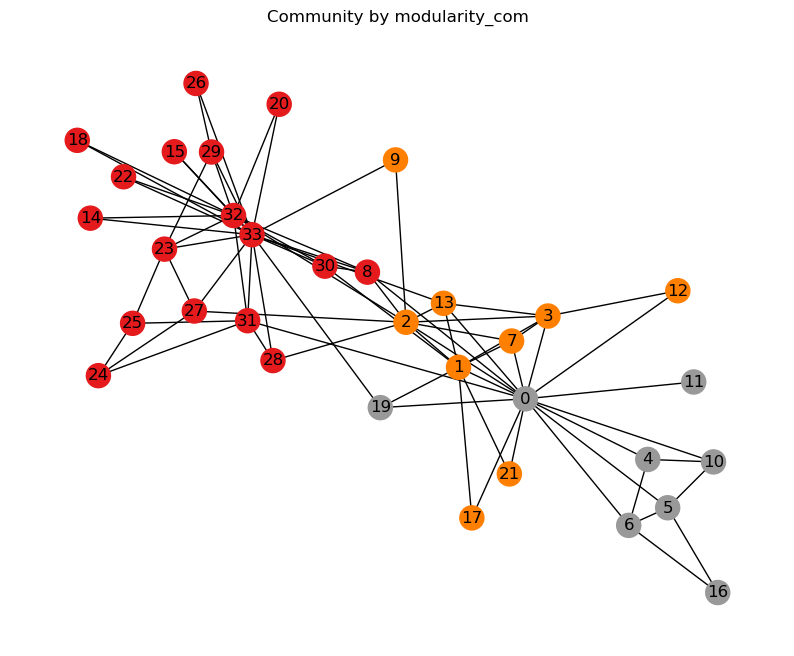

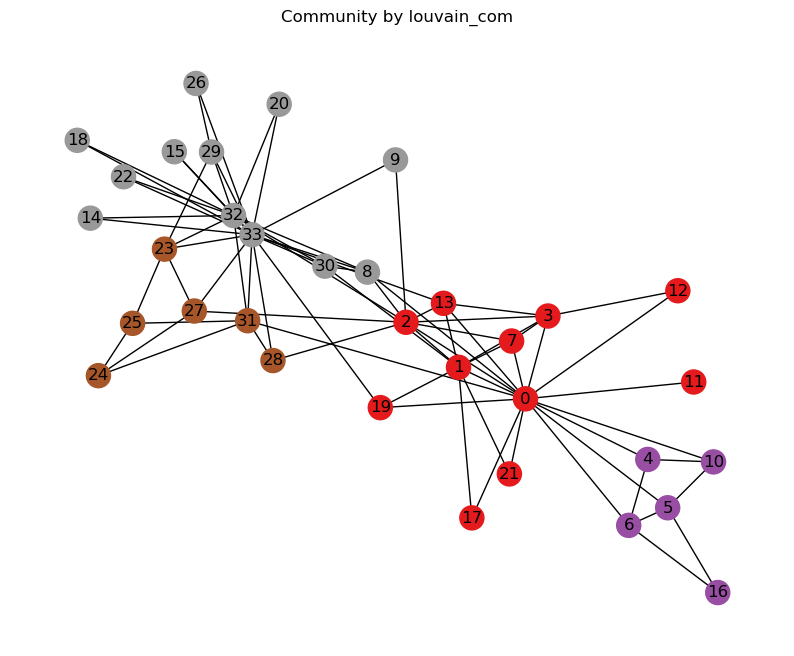

In [8]:
draw_community_graph(G, pos, 'modularity_com')
draw_community_graph(G, pos, 'louvain_com')

실제로 해보니까 어떠신가요? 사실 실행하는 것은 매우 간단합니다. 그리고 결과가 알고리즘마다 매우 다양하다는 것을 쉽게 확인하실 수 있습니다. 심지어 이 두 알고리즘은 둘 다 모듈도에 기반한 것인데도 그렇죠. 

이건 자연스러운 현상입니다. 4절 초반에 말씀드렸듯 커뮤니티 탐지 문제는 어렵습니다. 두 가지 문제(계산 복잡도, 지표 타당성)를 나름대로 해결해야 하는데 그게 쉽지 않다고 말씀드린건, 이 '어렵다'의 내용을 나름대로 설명드린 것입니다. 그러다보니 각 알고리즘은 나름의 방식의 타협과 그 과정에서 강조하는 초점과 강점이 있기 마련입니다. 우리가 살펴본 알고리즘도 그렇습니다. 워크트랩은 국소적 구조 탐지를, 루뱅은 계산 효율성을, SBM은 이론적 정의의 정합성을 전면에 초점과 강점으로 내세워서 커뮤니티 탐지를 시도합니다. 그리고 이처럼 두드러진 부분이 다들 명확하기에, 결과가 다른 것도 오히려 자연스럽습니다. 

그러면 자연히 '무엇을 써야 하는가?'라는 고민이 들죠. 제 생각에 토큰 네트워크 분석처럼 '정답'이 따로 없는 상황에서는 **이론적 정당성**을 세우는 것이 가장 중요합니다. 즉 나의 목표와 데이터의 특징을 고려했을 때 이론적으로 가장 적절한 알고리즘을 선택하고 그걸 설명하는거죠. 커뮤니티 탐지는 다양한 목표에 활용될 수 있습니다. 토큰 네트워크를 분석하는 상황으로 한정해도 마찬가지입니다. 주제를 찾아내고 싶을 수도 있고, 프레임을 찾아내고 싶을 수도 있죠. 그 구체적 목표에 따라 내가 추적해야 하는 커뮤니티의 성격과 구조가 달라질 수 있습니다. 그렇기에 내 목표가 뭔지 분명히 하고, 내 자료의 특징을 이해한 상태에서 어떤 알고리즘이 적합한지 고민해야 합니다. 앞서 말씀드린 알고리즘의 강점과 초점이 내 목표와 데이터에 부합하는지 판단해야 한다는 말입니다. 그리고 이를 위해서는 각 알고리즘의 특징을 고려하는 것이 분명 도움이 될 것이라 생각합니다. 그렇게 내가 왜 이 알고리즘을 선택했는지를 스스로와 타인에게 잘 설명할 수 있을 때, 분석 결과가 가지는 힘과 함의가 커질 것입니다. 

## 5. 커뮤니티 탐지 알고리즘 결과 평가 및 비교

### 5.1. 결과 평가 및 비교의 필요성

다음으로는 커뮤니티 탐지 알고리즘의 결과, 즉 잠정적인 커뮤니티 구조가 주어졌을 때 이를 평가하거나 비교할 때 사용하는 지표에 대해서 알아보겠습니다. 구체적으로, Adjusted Rand Index (ARI)와  Normalized Mutural Information (NMI) 를 살펴볼 것입니다. 이들은 커뮤니티 탐지 결과로 주어지는 구조 정보 사이의 유사성을 계량하는 지표입니다. 보다 일반적으로 말하자면 데이터 클러스터링 구조들 사이의 유사성을 계량하는 지표인데, 커뮤니티 탐지 결과가 결국 노드들의 클러스터링 구조이므로, 네트워크 과학에서 커뮤니티 탐지 결과 평가에 흔히 활용됩니다. 

이 둘은 주로 '정답 구조'가 있을 때 우리가 적용한 탐지 알고리즘의 결과가 그 정답에 얼마나 부합하는지 계량하기 위해 사용되곤 합니다. 즉 분석결과와 정답과의 유사성을 계량하는 일종의 성능 평가 지표로 활용되는 셈이지요. 커뮤니티 탐지의 정답이 주어져 있는 경우가 종종 있습니다. 우리가 앞서 살펴본 가라데 클럽 네트워크 데이터가 좋은 예입니다. 이 클럽은 최종적으로 두 개의 파벌에 따라 분리되었다고 알려져 있고, 어떤 노드가 어떤 파벌에 해당하는지 알려져 있습니다. 그 정보가 데이터에 포함되어 있습니다. 즉 커뮤니티가 추적하려 한 파벌의 '정답'이 알려져 있는 것입니다. 그렇기에 커뮤니티 탐지 알고리즘의 적용 결과가 이 정답과 얼마나 가까운지 계량하는 것이 자연스러운 일입니다. 실제로 가라데 클럽 네트워크는 새로운 커뮤니티 탐지 알고리즘이 적용되는 모의고사 같은 용도로 많이 활용되지요. 

그런데 언어 자료를 네트워크라는 관점에서 분석하여 주제나 프레임 같은 잠재 변수를 알아내는 작업에서는 이런 정답이 주어지는 경우가 드뭅니다. 그게 알려져 있다면 굳이 분석을 할 필요가 없지요. 즉 애초에 우리에게 주어지는 자료는 그저 글 뭉치일 뿐인 경우가 대부분입니다. 목표에 따라 다르지만, 커뮤니티 탐지를 활용한다면 거기에서 두드러진 주제나 프레임 혹은 담론 등에 관심을 탐색하려는 경우가 많습니다. 그리고 이것은 명확히 주어져 있지 않은, 말 그대로 잠재 변수입니다. 일종의 비지도학습과 같은 상황이 일반적이라는 말입니다. 

그러면 우리 상황에서는, 즉 마음의 구조를 분석하기 위해 언어 자료를 토큰 네트워크로 바라보고 분석하는 상황에서는, 그래서 정답 구조가 불분명하여 정답 재현 성능을 보는 일이 드문 상황에서는, ARI나 NMI 같은 지표가 필요하지 않는 것일까요? 그렇지는 않습니다. 크게 두 가지 이유 때문에 그렇습니다. 

첫 번째, 커뮤니티 탐지 결과를 비교하고 분석하는 일이 필요합니다. 결과로 주어지는 커뮤니티 구조를 분석하는 일이 꼭 '정답'과 비교하는 일에만 한정되지 않습니다. 그거 이외에도 여러 가지 비교 분석이 필요한 상황을 떠올릴 수 있습니다. 가장 빈번한 상황은 두 가지입니다. 

1) 결과의 안정성 분석: 데이터에 근거한 계량적 분석에서 흔히 하는 일인데, 내가 얻은 결과가 내가 설정한 구체적인 분석 설정 때문에 등장한 우연한 결과가 아닌지 확인해보는 절차입니다. 예를 들어 토큰 네트워크의 커뮤니티 탐지 결과를 얻었다고 하죠. 그런데 그 구조가 내가 선택한 알고리즘, 나아가 내가 선택한 특정한 하이퍼파라미터 설정에서만 나오는 특이한 구조라면 어떨까요? 그러면 많은 경우 분석자는 곤란합니다. '주제'나 '프레임'과 같은 잠재 구조에 관심이 있어서 그걸 포착하려고 분석을 시작한 셈인데, 정말 그것이 자료에 강하게 존재한다면, 비슷한 논리의 알고리즘이나 크게 다르지 않은 설정 변화에는 비슷한 결과가 나와줘야 하기 때문입니다. '내가 파악한 주제는 A알고리즘의 B세팅에서만 탐지됩니다'라고 말할 수는 없으니까요^^;; 그래서 분석의 타당성을 입증하기 위해, '본질은 건드리지 않은채 분석 알고리즘이나 세팅을 약간 변화시켜보고, 결과가 대동소이함을 확인하는 과정'을 거칠 때가 많습니다. '강건성 점검 (robustness check)' 혹은 '민감도 분석 (sensitivity analysis)'이라는 말로 불리는 절차가 이것입니다. 그런데 이를 하기 위해서는 분석 결과, 이 경우에는 커뮤니티 탐지 결과의 유사성을 계량적으로 평가하는 지표가 필요합니다. 앞서 말한 ARI나 NMI를 여기에 쓸 수있습니다. 이들에게 '정답'과 '내 분석 결과'를 주고 유사성을 평가하게 되면 그건 앞서 말한 성능 평가가 되지만, 이들에게 '세팅 1의 결과'와 '세팅 2의 결과'를 주고 유사성을 평가하면 그건 결과의 유사성 비교가 되는거죠.

2) 분석 논리 변화에 따른 변화 정도 분석: 반대의 경우도 생각해볼 수 있습니다. 우리가 관심을 두는 어떤 분석의 초점이 있다고 하겠습니다. 예를 들어 나는 토큰 커뮤니티가 간접 연결 거리를 길게 가지지 않으면서 서로 조밀하게 연결된 토큰 집합이었으면 좋겠다고 생각할 수 있습니다. 혹은 해상도 문제가 나에게는 매우 중요해서, 작은 규모의 커뮤니티가 많이 포착되었으면 좋겠다고 생각할 수 있습니다. 그리고 이를 위해 알고리즘을 선택할 수 있죠. 이것이 제대로 작동했는지 알기 위해서는, 그렇지 않은 알고리즘의 탐지 결과와 내 결과가 얼마나 다른지 확인해 보는 분석이 유용할 수 있습니다. 이 경우에도 ARI나 NMI 같은 커뮤니티 구조간 유사성을 평가하는 지표가 유용할 수 있습니다. 즉 나의 초점 변화 혹은 관심 변화에 따라 결과가 달라지고 있는지 확인하는 분석인 셈입니다.

두 번째, 드물긴 하지만 토큰 네트워크 분석에서도 정답에 해당하는 구조나 적어도 참조점으로 활용할 만한 구조가 주어지는 경우를 상상해 볼 수 있습니다. 예를 들어 신문기사를 수집하면, '섹션 정보'가 들어오는 경우가 있습니다. 정치, 사회, 스포츠, 뭐 이런거죠. 거기서 주로 등장하는 토큰도 식별이 가능합니다. 그러면, 이들을 다 모아서 분석했을 때, 섹션 구조라는 정보가 잘 재현되는지 평가해볼 수 있습니다. 혹은 국회의사당 회의록에서 야당의원의 발언과 여당의원의 발언이 체계적으로 차이난다는 가설이 존재한다면, 실제 토큰 네트워크의 커뮤니티 탐지 결과가, 각 정치 세력의 주요 사용 단어를 구분하는지 볼 수도 있지요. 아예 좀 방법론적으로, 누군가가 토큰 네트워크에서 언어적 잠재 구조 탐지를 위해 적용되는 알고리즘의 성능 평가를 위해 '모의고사 데이터', 즉 벤치 마크 데이터를 만들어 버리는 상황도 상상해 볼 수 있습니다. 요컨대, 드물긴 하지만 '정답'에 해당하는 구조와 결과의 유사성을 평가하는 일이 아주 없지는 않습니다. 

나아가 이외에도 창의적인 지표 활용이 존재할 수 있지요. ARI나 NMI를 꼭 어디에만 써야 한다는 법칙은 없습니다. 기본적으로 이들은 커뮤니티 구조 (좀 더 일반화 시켜 말하자면 데이터의 클러스터링 구조)의 유사성을 계량할 수 있는 지표인데, 여기서 언급하지 않은 활용법이 존재할 수 있습니다. 분석을 하고 연구를 하는 상황과 목표는 너무나 다양하니까요. 그러니 우리, 일단 ARI와 NMI가 어떻게 작동하는지 한 번 알아봅시다. 

### 5.2. 커뮤니티 구조간 유사성 계량 문제의 특징

자 그럼 본격적으로 ARI와 NMI에 대해 알아보기 전에, '커뮤니티 구조' 혹은 '데이터 클러스터링 구조'의 유사성을 측정하는 문제가 가지는 특징에 대해 알아봅시다. 사실 두 가지 서로 다른 구조의 유사성이나 차이를 보는건 쉬운 일 같지만, 생각보다 까다로운 면이 있습니다. 좀 전통적으로, 앞서 말했듯 '정답'이 있는 상황을 가져와서 생각해봅시다. 여기에 대표적인 데이터가, 우리가 이미 실습에서 사용한 Zachary Karate network 데이터입니다. Networkx는 그 정답을 노드 속성으로 표현하고 있습니다. 한 번 살펴봅시다. 

In [9]:
import networkx as nx
G = nx.karate_club_graph()
G.nodes(data = True)

NodeDataView({0: {'club': 'Mr. Hi'}, 1: {'club': 'Mr. Hi'}, 2: {'club': 'Mr. Hi'}, 3: {'club': 'Mr. Hi'}, 4: {'club': 'Mr. Hi'}, 5: {'club': 'Mr. Hi'}, 6: {'club': 'Mr. Hi'}, 7: {'club': 'Mr. Hi'}, 8: {'club': 'Mr. Hi'}, 9: {'club': 'Officer'}, 10: {'club': 'Mr. Hi'}, 11: {'club': 'Mr. Hi'}, 12: {'club': 'Mr. Hi'}, 13: {'club': 'Mr. Hi'}, 14: {'club': 'Officer'}, 15: {'club': 'Officer'}, 16: {'club': 'Mr. Hi'}, 17: {'club': 'Mr. Hi'}, 18: {'club': 'Officer'}, 19: {'club': 'Mr. Hi'}, 20: {'club': 'Officer'}, 21: {'club': 'Mr. Hi'}, 22: {'club': 'Officer'}, 23: {'club': 'Officer'}, 24: {'club': 'Officer'}, 25: {'club': 'Officer'}, 26: {'club': 'Officer'}, 27: {'club': 'Officer'}, 28: {'club': 'Officer'}, 29: {'club': 'Officer'}, 30: {'club': 'Officer'}, 31: {'club': 'Officer'}, 32: {'club': 'Officer'}, 33: {'club': 'Officer'}})

자 그럼 우리에게는 정답과, 각 알고리즘이 분류한 결과가 있습니다. 그걸 보기 좋게 노드 속성으로도 넣고, 개별 리스트로 정리해봅시다. 

In [10]:
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import louvain_communities

modularity_com = greedy_modularity_communities(G)
louvain_com = louvain_communities(G)

def communities_to_dict(communities):
    mapping = {}
    for i, com in enumerate(communities):
        for node in com:
            mapping[node] = i
    return mapping

modularity_com_dict = communities_to_dict(modularity_com)
louvain_com_dict = communities_to_dict(louvain_com)

nx.set_node_attributes(G, modularity_com_dict, "M")
nx.set_node_attributes(G, louvain_com_dict, "L")

G.nodes(data = True)

NodeDataView({0: {'club': 'Mr. Hi', 'M': 2, 'L': 1}, 1: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 2: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 3: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 4: {'club': 'Mr. Hi', 'M': 2, 'L': 0}, 5: {'club': 'Mr. Hi', 'M': 2, 'L': 0}, 6: {'club': 'Mr. Hi', 'M': 2, 'L': 0}, 7: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 8: {'club': 'Mr. Hi', 'M': 0, 'L': 3}, 9: {'club': 'Officer', 'M': 1, 'L': 3}, 10: {'club': 'Mr. Hi', 'M': 2, 'L': 0}, 11: {'club': 'Mr. Hi', 'M': 2, 'L': 1}, 12: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 13: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 14: {'club': 'Officer', 'M': 0, 'L': 3}, 15: {'club': 'Officer', 'M': 0, 'L': 3}, 16: {'club': 'Mr. Hi', 'M': 2, 'L': 0}, 17: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 18: {'club': 'Officer', 'M': 0, 'L': 3}, 19: {'club': 'Mr. Hi', 'M': 2, 'L': 1}, 20: {'club': 'Officer', 'M': 0, 'L': 3}, 21: {'club': 'Mr. Hi', 'M': 1, 'L': 1}, 22: {'club': 'Officer', 'M': 0, 'L': 3}, 23: {'club': 'Officer', 'M': 0, 'L': 2}, 24: {'club': 'Officer', 'M': 

In [11]:
y_true = [d["club"] for n, d in G.nodes(data=True)]
y_pred_M = [d["M"] for n, d in G.nodes(data=True)]
y_pred_L = [d["L"] for n, d in G.nodes(data=True)]

print(y_true, '\n')
print(y_pred_M, '\n')
print(y_pred_L, '\n')

['Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Officer', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer'] 

[2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 

[1, 1, 1, 1, 0, 0, 0, 1, 3, 3, 0, 1, 1, 1, 3, 3, 0, 1, 3, 1, 3, 1, 3, 2, 2, 2, 3, 2, 2, 3, 3, 2, 3, 3] 



자 이제 정답과 두 가지 결과가 있습니다. 그렇다면 정답과 각 결과 사이의 유사성은 물론, 두 결과 사이의 유사성 혹은 차이를 평가할 수 있어야겠죠? 그런데 막상 하려면 좀 애매합니다. 우리가 아는 가장 쉬운 점수 매기기 혹은 평가 방법은 '일치 여부'를 살펴보는 것입니다. 이 과정에서 일단 확인할 수 있는 일차적인 난감함은 기호가 임의적이라는 것입니다. 어떤 커뮤니티를 Mr. Hi라고 표현할 수도 있고, 1이라고 표현할 수도 있죠. 그러니 단순 일치를 보는 것은 그리 좋은 방법이 아닙니다. 

그렇다면, 같은 체계의 기호로 맞춰주면 되지 않을까요? 이건 우리가 흔히 사용하는 해결책입니다. 예를 들어 상품에 대한 리뷰를 긍정/부정으로 분류하는 기계가 있다고 합시다. 정답은 '긍정', '부정' 이런식으로 각 리뷰마다 기록되어 있습니다. 그리고 우리는 우리의 자동 분류기의 성능을 평가하고 싶습니다. 그런데 우리 분류기는 긍정을 0, 부정을 1이라고 표기합니다. 임의적 기호로 표기하는거죠. 그럼 사실 간단합니다. 0을 긍정, 1을 부정으로 바꾸든가, 아니면 거꾸로 바꾸면 됩니다. 즉 하나의 체계의 기호로 만들어 버리면 됩니다. 그러면 일치 여부를 통해 성능을 평가할 수 있습니다. 

그런데 커뮤니티 소속 레이블은 이렇게 하기가 쉽지 않습니다. 예를 들어 greedy modularity maximazation 함수의 결과로 주어진 1번 노드의 레이블을 어떻게 하면 좋을까요? 2로 주어졌는데, 일단 이게 맞다고 치고, 2는 Mr.Hi와 대응되는 것으로 볼까요? 그런데 2번 노드는 또 1이 나오는데요. 일단 1은 'Officer'와 대응되는 것으로 합시다. 그런데 그러면 0은 어떻게 하면 좋을까요. louvain 결과는 3까지 나오니 더 난감합니다. 

왜 이게 쉽지 않을까요? 본질적으로 '속성 정보'와 '관계 정보'의 차이 때문이라고 볼 수 있습니다. 앞서 말한 '긍정' '부정'과 같은 정보는 속성 정보입니다. 즉 관찰치에 내재하는 속성이고, 다른 관찰치에 영향을 받지 않습니다. 긍정이라는 속성은 그걸 '긍정'이라고 표기하건 '0'이라고 표기하건, 안정적이고 독립적으로 존재합니다. 그러니 기호의 종류를 맞추는 것도 간단합니다. 관찰치마다 독립적으로 존재하는 속성을 표현하는 하나의 규칙을 쓰기만 하면 되니까요. 

그런데 커뮤니티 레이블은 관계 정보입니다. 그것은 노드 자체가 가진 속성이 아니라, 노드들의 관계가 가지는 구조적 특징을 기호로 표현한 것입니다. 즉 1번 노드가 가진 커뮤니티 레이블은 1번 노드가 가진 속성 정보를 표현하는 것이 아니라, 다른 노드와의 관계에 대한 정보를 표현하고 있습니다. 예를 들어 <1,2,3,7,8번 노드는 같은 커뮤니티에 속한다>는 정보를 표현하기 위한 기호라는 것입니다. 이런 정보는 개별 노드가 아니라 전체 노드를 포괄해서 봐야 그 의미가 드러납니다. 그렇기에 개별 관찰치에 속하는 정해진 어떤 값 (속성) 을 기준으로 기호를 정리하는게 불가능합니다. 애초에 그런 속성을 가리키는 값이 아니기 때문입니다. 그러니 '관찰치 속성을 가리키는 기호 체계를 통일시켜 일치 여부를 본다'는 접근이 어려운 것이죠. 

그럼 어떻게 해야 할까요? 어떤 알고리즘 결과로 만들어진 관계적 정보가 정답 구조나 다른 알고리즘 결과가 표현하는 관계적 정보에 얼마나 가까운지 보는 새로운 방법이 필요합니다. 그건 적어도 개별 관찰치에 집중하는게 아니라 다른 관찰치와의 관계, 나아가 전체 관찰치가 표현하는 정보를 포괄하여 비교하는 방법이어야 할 것입니다. 

그리고 우리가 살펴볼 ARI (adjusted Rand Index)나 NMI (Normalizaed Mutual Information) 같은 지표가 바로 이런 방법을 활용하여 성과를 측정합니다. 

### 5.3. Adjusted Rand Index

먼저 ARI는 관찰치 간 관계적 정보에 집중합니다. ARI는 모든 노드쌍을 고려합니다. 노드쌍이 있고, 두 종류의 커뮤니티 구조가 있다고 할 때, 다음과 같은 네 가지 가능성이 있습니다. 편의상 두 종류의 커뮤니티 구조는 '기준점'과 '분석 결과'라고 부르겠습니다. 분석 결과는 내가 선택한 알고리즘의 결과를 의미합니다. 기준점에 정답 구조가 들어가면 성능 평가가 되는거고, 또다른 알고리즘의 결과가 들어가면 두 결과 사이의 유사성 평가가 되겠네요. 

1. 기준점에서 같은 커뮤니티, 분석 결과에서도 같은 커뮤니티
2. 기준점에서 다른 커뮤니티, 분석 결과에서도 다른 커뮤니티
3. 기준점에서 같은 커뮤니티, 분석 결과에서는 다른 커뮤니티
4. 기준점에서 다른 커뮤니티, 분석 결과에서는 같은 커뮤니티

1과 2는 잘 맞는 상황이죠. 3과 4는 틀린 상황입니다. RI (Rand Index) 는 맞는 노드쌍의 갯수를 전체 노드쌍의 갯수로 나눈 값입니다.  

$$ 
RI = \frac{\text{1 혹은 2에 해당하는 노드쌍 숫자}}{\text{모든 노드쌍 숫자}}
$$

인 것이지요. 그런데 여기에는 문제가 있는데, 우연히 일치하는 숫자가 많을 수도 있다는 점입니다. 예를 들어 커뮤니티 숫자가 매우 많으면, 대부분 다른 소속이 될 것이고, 그래서 우연히 2번 상황에 해당하는 노드쌍이 많아서 RI가 높아질 수도 있습니다. 또 어떤 경우에는 우연히 양쪽에서 같은 커뮤니티에 속하는 노드가 많아질 수도 있지요. 그런 우연한 일치를  보정해준 것이 ARI입니다. 수식은 아래와 같습니다. 

$$
ARI \;=\;
\frac{
\displaystyle \sum_{i=1}^r \sum_{j=1}^s \binom{n_{ij}}{2}
\;-\;
\displaystyle \frac{
\left(\sum_{i=1}^r \binom{a_i}{2}\right)
\left(\sum_{j=1}^s \binom{b_j}{2}\right)
}{
\binom{n}{2}
}
}{
\displaystyle
\frac{1}{2}\!\left[
\sum_{i=1}^r \binom{a_i}{2}
+
\sum_{j=1}^s \binom{b_j}{2}
\right]
\;-\;
\frac{
\left(\sum_{i=1}^r \binom{a_i}{2}\right)
\left(\sum_{j=1}^s \binom{b_j}{2}\right)
}{
\binom{n}{2}
}
}
$$

우리가 꼭 이걸 이해해야 하나 싶지만, 그래도 나왔으니 한 번 살펴봅시다. 혹시 나중에 우리도 이런거 만들어야 할지도 모르잖아요?^^ 일단 ARI 수식의 배경은 $ARI = \frac{실제일치 - 우연기대일치}{최대가능일치 - 우연기대일치}$ 로 짜여져 있다는 점을 기억하고 출발하겠습니다. 즉, 관찰치에서 우연히 기대할 수 있는 수준을 뺀 상태에서 그런 지표가 가질 수 있는 최대값을 나누어준 것이라고 보면 되겠죠. 그렇게 하는 것 자체는 그러려니 싶습니다. 우연을 감안해서 표준화를 하는거죠. 

그런데 $\binom{n_{ij}}{2}$을 i와 j의 모든 조합에 대해서 해서 더한게 왜 '기준점에서도 같은 커뮤니티에 속하고 분석 결과에서도 같은 커뮤니티에 속한 노드쌍 갯수'가 되는건지 쉽게 이해되지 않는데요. 이건 기준점의 집단과 분석 결과가 내놓은 집단을 서로 교차해가면서 양쪽 모두 같은 집단에 속한 노드를 우선 식별하고, 그 안에서 두 개의 노드쌍이 몇 개나 나올 수 있는지 세는 방식이라고 생각하면 됩니다. 즉 $n_{ij}$는 기준점에서 i번째 집단에 속하고 분석 결과에서는 j번째 집단에 속하는 모든 노드의 갯수를 의미하고 있다고 보시면 됩니다. 예를 들어 보죠. 기준점은 다섯 개의 노드를 이렇게 분할 했습니다. 기준점 1번 집단 = {a,b,c}, 기준점 2번 집단 {d,e}. 반면 내가 선택한 탐지 알고리즘이 내놓은 분석 결과의 분할은 이렇습니다. 분석 결과 1번 집단 {a,b}, 분석 결과 2번 집단 {c,d,e}. 자 여기서 양쪽 분할 세팅 모두에서 같은 집합에 속한 노드쌍 수를 세려면 어떻게 하면 될까요? 양쪽 두 개의 집단을 교차해가며 함께 소속된 원소의 숫자를 세고, 그 안에서 2개 쌍 갯수를 세면 됩니다. 아래와 같은 식이죠. 

기준점 1번 집합 &cap; 분석 결과 1번 집합: {a, b} -> 여기서 나올 수 있는 2개 쌍 수? 1개  
기준점 1번 집합 &cap; 분석 결과 2번 집합: {c}  -> 여기서 나올 수 있는 2개 쌍 수? 0개  
기준점 2번 집합 &cap; 분석 결과 1번 집합: {}  -> 여기서 나올 수 있는 2개 쌍 수? 0개  
기준점 2번 집합 &cap; 분석 결과 2번 집합: {d,e}  -> 여기서 나올 수 있는 2개 쌍 수? 1개  

다 합치면? 총 2개  

즉, {a,b,c,d,e} 다섯 개 노드로 이루어진 노드쌍 중에서 양쪽 분할에서 모두 같은 집합에 속한 노드쌍은 (a, b)와 (d, e) 두 개입니다. 이걸 위와 같은 식으로 구하는거죠. 



그럼 남은건 '노드쌍이 양쪽에서 같은 집합에 소속되는 횟수의 우연한 기대값'과 '노드쌍이 양쪽에서 같은 집합에 소속될 수 있는 최대 수치'를 구하는 것이군요. 첫번째 부터 해보죠. 우연한 기대값은 어떻게 구할까요? 간단한 확률을 적용해 보면 <전체 노드쌍 갯수> X <어떤 노드가 기준점 분할에서 우연히 같은 집합에 소속될 확률> X <어떤 노드가 분석 결과 분할에서 우연히 같은 집합에 소속될 확률> 입니다. 각각을 정리해봅시다. 

$$
\begin{aligned}
\text{전체 노드쌍 개수} &= \binom{N}{2}\\
\text{어떤 노드가 기준점 분할에서 우연히 같은 집합에 소속될 확률} &= \frac{\sum_{i=1}^r{\binom{a_i}{2}}}{\binom{N}{2}}\\
\text{어떤 노드가 분석 결과 분할에서 우연히 같은 집합에 소속될 확률} &= \frac{\sum_{j=1}^s{\binom{b_j}{2}}}{\binom{N}{2}}
\end{aligned}
$$

a_i는 기준점에서 i번째 집합의 노드 갯수, b_j는 분석 결과에서 j번째 집합의 노드 갯수라고 생각하면 됩니다. 그리고 이 세 개가 곱해지면, 지금 ARI 수식에서 분자와 분모에서 빼고 있는 표현이 나옵니다. 

두 번째로 최대값을 볼까요? '노드쌍이 양쪽에서 같은 집합에 소속될 수 있는 이론적 최대 수치'는 왜 $\frac{1}{2}\!\left[
\sum_{i=1}^r \binom{a_i}{2}
+
\sum_{j=1}^s \binom{b_j}{2}
\right]$ 이렇게 정의될까요. 일단 '노드쌍이 양쪽에서 같은 집합에 소속된 수치'가 $\sum_{i=1}^r{\binom{a_i}{2}}$보다도 작고 $\sum_{j=1}^s{\binom{b_j}{2}}$보다도 작아야 한다는 건 쉽게 이해가 되실 겁니다. 왜냐하면 각자는 각 분할에서 같은 집합으로 분류된 노드쌍의 갯수를 가리키는데, 양쪽에서 동시에 같은 집합으로 분류된 노드쌍의 갯수가 어느 한쪽 분할에서 같이 소속된 노드쌍의 갯수를 넘어설 수는 없기 때문입니다. 그래서 사실 엄밀히 말하면, 이론적 최대치는 $\min(\sum_{i=1}^r{\binom{a_i}{2}}, \sum_{j=1}^s{\binom{b_j}{2}})$이 되어야 합니다. 그런데 이 수치를 만든 사람들 (Hubert & Arabie)는 이론적 최대치 대신 평균을 내는 쪽을 택했습니다. 왜 그랬는지 저는 잘 모르겠습니다만, 아마도 수식적 단순함과 양쪽 분할 혹은 클러스터링을 균일하게 다루려는 의도를 보이려는 것 혹은 실질적 문제 없음 때문이 아니었을까 합니다. 

뭐 여튼 이런 과정을 거쳐 ARI가 정의되는데요, 사실 또 생각해보면 찝찝한 부분이 없지 않습니다. 왜냐하면 RI를 adjust해주는게 컨셉인데, RI와 약간 달라보이는 것이 여전히 있거든요. RI는 <기준점에서 같은 커뮤니티, 분석 결과에서도 같은 커뮤니티> <기준점에서 다른 커뮤니티, 분석 결과에서도 다른 커뮤니티> 두 경우에 해당하는 노드쌍 숫자를 합해서 분자에 넣었습니다. 그런데 ARI는 사실상 <기준점에서 같은 커뮤니티, 분석 결과에서도 같은 커뮤니티>에 해당하는 노드쌍 숫자만을 수식에서 고려하고 있습니다. 이래도 되는걸까요? 그런데 그래도 됩니다.

일단 이론적으로 보자면, <기준점에서 다른 커뮤니티, 분석 결과에서도 다른 커뮤니티>에 해당하는 노드쌍 숫자는 <기준점에서 같은 커뮤니티, 분석 결과에서도 같은 커뮤니티>에 속하는 노드쌍 숫자가 주어지고, 기준점이 커뮤니티를 어떤 규모의 집합들로 분할했는지와 분석 결과가 커뮤니티를 어떤 규모의 집합들로 분할했는지가 결정되면, 자동으로 결정되는 값입니다. 그래서 명시적으로 고려하지 않고 암묵적으로 고려할 수 있습니다. 

그리고 명확히 RI를 조정해주는 방향으로 가도, 결국 이렇게 됩니다. 다시 한 번 상황을 정리해봅시다. RI는 네 가지 상황을 고려합니다. 이걸 편의상 a,b,c,d라고 하겠습니다. 

- a. 기준점에서 같은 커뮤니티, 분석 결과에서도 같은 커뮤니티
- b. 기준점에서 다른 커뮤니티, 분석 결과에서도 다른 커뮤니티
- c. 기준점에서 같은 커뮤니티, 분석 결과에서는 다른 커뮤니티
- d. 기준점에서 다른 커뮤니티, 분석 결과에서는 같은 커뮤니티

RI는 $\frac{a+b}{\binom{N}{2}}$ 입니다. 그럼 ARI는 직관적으로 $\frac{(a+b)-E(a+b)}{MAX(a+b)-E(a+b)}$가 될 것입니다. 그런데 재미있는 것은 (a+b)-E(a+b)를 풀어서 써보면, 결국 2(a-E(a))가 나오고, MAX(a+b)-E(a+b)도 결국 2(MAX(a)-E(a))가 나온다는 것입니다. 일단 a,b,c,d를 수식으로 표현해 보면 다음과 같습니다. 

- a: $\sum_{ij}{\binom{n_{ij}}{2}}$
- b: $\binom{N}{2} - a - c - d$
- c: $\sum_{i}{\binom{a_i}{2}} - a$
- d: $\sum_{j}{\binom{b_j}{2}} - a$

각각 하나하나 살펴보면 특별히 이상할 건 없으실 겁니다. 핵심은 b가 a,c,d의 표현으로 정리될 수 있다는 겁니다. 그러면 a+b는 $\binom{N}{2} - c - d$ 가 되죠. 이건 풀어보면 $\binom{N}{2} - \sum_{i}{\binom{a_i}{2}} - \sum_{j}{\binom{b_j}{2}}+2a$가 됩니다. 이걸 기대값을 취하면, 즉 E(a+b)를 구하려면 이 표현 전체에 기대값을 걸면 됩니다. 그리고 기대값을 구하는 조건 (가정하는 세계)이 있어야 하는데, 그건 각 분할이 (즉 기준점과 분석 결과) 커뮤니티를 만드는 집합의 숫자와 각 집합의 규모는 고정한다는 조건입니다. 그러면 $\sum_{i}\binom{a_i}{2}$와 $\sum_{j}\binom{b_j}{2}$는 상수가 됩니다. $\binom{N}{2}$도 마찬가지고요. 결국 그럼 E(a+b)는 $\binom{N}{2} - \sum_{i}{\binom{a_i}{2}} - \sum_{j}{\binom{b_j}{2}}+2E(a)$가 되는거죠.  
그럼 a+b는 $\binom{N}{2} - \sum_{i}{\binom{a_i}{2}} - \sum_{j}{\binom{b_j}{2}}+2a$이고,  
여기서 $\binom{N}{2} - \sum_{i}{\binom{a_i}{2}} - \sum_{j}{\binom{b_j}{2}}+2E(a)$를 빼면 어떻게 되죠?  
2a-2E(a) 가 됩니다.
  
MAX(a+b)-E(a+b)는 어떨까요? 마찬가지로 상수와 max를 고려하면 MAX(a+b)는 결국 2MAX(a)가 됩니다. 그러면 이것도 2MAX(a)-2E(a)가 되는거죠. 그래서 총 정리를 해보면 

$$
\frac{(a+b)-E(a+b)}{MAX(a+b)-E(a+b)} = \frac{a-E(a)}{MAX(a)-E(a)}
$$
  
이렇게 정리되는거죠. 그리고 정리된 표현을 풀어서 쓴데 맨 처음 본 ARI 수식입니다. 그리고 이렇게 정리될 수 있는 이유는, 기대값과 최대값을 구하는 세계관 가정에서는 각 분할 (기준점과 분석 결과) 의 분할 규모 (몇 개의 집합, 각 집합의 규모)가 정해져 있고 (이걸 마진 고정이라고 합니다. random under fixed margins), 그렇다면 사실상 d 집합의 규모는 a 집합이 정해지면 자동으로 도출되기 때문입니다. 


수식을 이해하는데 좀 길게 왔지만, 여튼 ARI의 핵심은 노드쌍을 모두 고려하고, 그것이 각 분할에서 같은 집합으로 배분되었는지를 봅니다. 이건 지금 우리가 나눈 분할이 어떤 종류의 노드 간 관계를 표현하고 있는지를 고려하는 방식이죠. 정확히는 그렇게 표현되는 관계가 양 분할에서 얼마나 유사한지 계량하는 방식이라고 할 수 있습니다. 그러니까 우리가 살펴본 커뮤니티 탐지 결과가 기준점에 얼마나 가까운지 확인하는 방법으로 쓸 수 있는 것입니다. 앞서 커뮤니티 탐지 결과를 평가하는 것은 관찰치 속성과 측정 결과가 일치하는지 보는 통상적인 지표로는 불가능하다고 말했습니다. 그리고 ARI는 관찰치 속성이 아니라 관찰치들 사이의 관계가 양자에서 얼마나 유사한지 계량함으로써 이를 해내는 것이지요. 

### 5.4. Normalized Mutual Information

그런데 사실 ARI를 길게 설명했지만, 실무적으로 더 많이 활용되는 지표는 NMI입니다. ARI를 먼저 설명한 이유는 그 지표가 '관계 정보를 측정한다'는 것을 직관적으로 좀 더 잘 보여주기 때문이었습니다. 그렇다면 좀 더 많이 쓴다고 하는 NMI는 어떻게 커뮤니티 탐지 결과들 사이의 유사성 측정을 해낼까요? 일단 NMI가 MI의 normalized version임을 알아야 합니다. 즉 핵심 정보는 Mutural Information이라는 지표에서 온다는 것이지요. 그럼 MI는 뭘까요? MI는 아래와 같이 정의됩니다. 

$$
MI(U;V) = \sum_{i=1}^r \sum_{j=1}^s p(u_i, v_j) \, \log \left( \frac{p(u_i, v_j)}{p(u_i)\,p(v_j)} \right)
$$

미리 설명해야 할 점은, MI, NMI는 ARI와 전제가 다르고, 그래서 지표의 표기도 전혀 다른 것을 표현하고 있습니다. 앞서 살펴봤듯 ARI는 노드쌍의 종류에 근거한 지표입니다. 반면 NMI/MI는 커뮤니티 탐지 결과를 범주형 확률 변수(categorical random variable)로 해석합니다. 그리고 두 확률 변수 사이의 의존을 계량하는 방식으로 나아갑니다.  

사실 앞서 살펴본 예만 봐도, 커뮤니티 탐지 결과를 확률 변수로 보는 것이 자연스럽다는 것을 알 수 있습니다. 앞선 예로 돌아가죠. 

가라데 네트워크 커뮤니티 구조 정답: ['Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Officer', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer'] 

Greedy modularity maximization 알고리즘 결과: [2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 

둘은 값의 연쇄입니다. 각 위치마다 임의의 기호로 표현된 특정 노드의 커뮤니티 소속 레이블을 담고 있지요. 이걸 categorical random variable로 해석할 수 있습니다. 첫 번째 값의 연쇄는 'Mr. Hi'와 'Officer'라는 두 개의 값을 가진 확률 변수의 샘플이고, 두 번째 값의 연쇄는 0,1,2라는 세 개의 값을 가진 확률 변수의 샘플이라고 볼 수 있습니다. 그리고 두 확률 변수는 각 노드를 축으로 동시 출현 여부라는 관계를 맺고 있습니다. 즉, 각 노드를 축으로 결합 분포 (joint distribution)을 형성하는 것이지요. 마치 설문에서 10명을 조사했을 때, '성별'이라는 확률 변수 (값의 범위는 남성, 여성, 기타) 와 '종교' 라는 확률 변수 (값의 범위는 기독교, 불교, 기타) 가 사람을 기준으로 결합 분포를 형성하는 것처럼요.

그러면 MI가 하는 것은 무엇이냐? 앞서 말했듯 두 확률 변수 사이의 의존을 계량합니다. 좀 직관적으로 표현하면, 하나의 확률 변수의 값이 알려지면, 다른 하나의 확률 변수 값을 추정하는데 어느 정도로 도움이 되는지를 계량합니다. 만약 이런게 가능하다면, 커뮤니티 탐지 결과에 적용하면 MI는 이런 질문에 답할 수 있게 되죠. '어떤 커뮤니티 탐지 알고리즘의 결과가 주어지면 기준점으로 제시된 커뮤니티 구조를 추정하는데 얼마나 도움이 되는가?' 이건 사실상 내가 선택한 커뮤니티 탐지 알고리즘의 결과가 기준점과 얼마나 유사한지 살펴보는 지표라고 할 수 있고, 그래서 알고리즘의 성능을 평가하거나 결과들의 유사성을 계량하는 용도로 사용될 수 있는 것입니다. 

그럼 구체적으로 이걸 어떻게 할까요? MI는 정보 이론을 활용하여 이걸 해냅니다. 즉 두 확률 변수 사이의 정보 공유량을 계산하는 거죠. 이걸 이해하기 위해서는 엔트로피(entropy)라는 개념을 알아야 합니다. 물리학 용어로 많이 알려져 있는데, 정보 이론에서도 '불확실정도'를 표현하는 개념 쓰입니다. 클로드 셰넌이 1948년, 무려 자신의 **석사 논문에서 제안한 개념**인데요, 여담이지만 이 분은 자신의 석사 논문으로 지금 우리가 살고 있는 디지털 세계의 기반을 제시한 셈이죠. 석사 과정 여러분 파이팅......전 이미 틀렸어요....

여튼 이 양반이 제시한 엔트로피는 다음과 같습니다. 어떤 확률 변수가 가진 불확실성은 아래처럼 표현할 수 있다는 것입니다. 

$$
H(X) = - \sum_{x \in \mathcal{X}} p(x)\, \log p(x)
$$


사실 저 수식은 그냥 보면 왜 저렇게 생겼는지 이해가 가지 않습니다. 저는 유튜브에서 'StatQuest with Josh Starmer'라는 채널에서 엔트로피 대한 참 훌륭한 직관적 설명을 발견했는데요 (https://youtu.be/YtebGVx-Fxw?si=RevmDLcHlYwRG3-Z), 아래 설명은 이 영상에 상당 부분이 기대고 있습니다.  

일단 직관적으로, 어떤 확률 변수의 불확실성은 그 확률 변수가 실현된 값, 즉 그 확률 변수의 표본에서 느껴지는 '놀라움'과 관련이 되어 있다는 점에서 시작하겠습니다. 우리는 확실한 것을 보고 놀라지 않습니다. 뭔가 아예 불가능한 것은 아니지만 예상하지 못한, 그래서 불확실한 일이 일어날 때 놀랍다고 생각하죠. 예를 들어 제가 늘 그랬듯이 머리칼을 갖고 이 수업 시간에 나타나면 여러분이 놀라지 않겠지만, 삭발을 하고 나타나면 놀라시겠죠. 일어나기 힘든 일이 일어났기 때문입니다. 그래서 놀라움은 아주 간단히 보면 확률의 역수로 표현할 수 있습니다. 아주 높은 확률로 일어나는 일은 별로 놀랍지 않고, 낮은 확률로 일어나는 일은 놀라우니까요. 그러면 이렇게 생각해 봅니다. 

$$
\text{어떤 일의 놀라움} = \frac{1}{\text{그 일이 일어날 확률}}
$$

여기에 더해 우리는 '놀라움의 지표'에 한 가지 속성이 더 있었으면 좋겠습니다. 두 개의 독립적인 사건에서 느껴지는 놀라움은 각각 놀라움의 합이 되었으면 좋겠습니다. 즉 A의 놀라움과 B의 놀라움을 합할 때, A와 B가 함께 일어나는 일의 놀라움이 되었으면 좋겠다는 말입니다. 그리고 식에 로그를 붙이면 이런 속성을 얻을 수 있습니다. 

$$
\begin{aligned}
\text{어떤 일의 놀라움} &= \log(\frac{1}{\text{그 일이 일어날 확률}})\\
\text{A 놀라움 + B 놀라움} &= \log(\frac{1}{A}) + \log(\frac{1}{B}) \\
&= \log(\frac{1}{AB})\\ 
&= \text{A와 B가 함께 일어난 일의 놀라움}
\end{aligned}
$$

엔트로피는 확률 변수 차원에서, 그 확률 변수가 가지는 '놀라움의 기대값'입니다. 확률 변수가 가질 수 있는 실제 사건은 하나가 아닙니다. 확률 변수라는 것 자체가 해당 변수가 가질 수 있는 사건값이 여럿인데 하나로 확정되지 않았음을 뜻합니다. '강사의 머리칼 존재 여부'라는 확률 변수가 있을 때, 그 값이 정해지지 않았습니다. 그중 확률이 높은 값도 있고 작은 값도 있을 것입니다. P('강사의 머리칼 존재 여부' = 머리칼 없음)은 확률이 낮고, P('강사의 머리칼 존재 여부' = 머리칼 있음) 은 확률이 높은 것처럼요. 그럼 확률 변수 입장에서는 각 사건이 가지는 놀라움을 각 사건의 확률에 기대어 기대값을 취할 수 있는거죠. 즉 이 확률 변수에서 가질 수 있는 놀라움의 기대값이 존재한다는 말입니다. 그걸 어떻게 정의할까요? 그냥 기대값 공식에 넣으면 됩니다. 각 사건이 가지는 놀라움의 척도에 가다가 해당 사건의 확률을 곱해서 그냥 다 더하면 되죠. 그걸 쓰면 이렇게 됩니다. 

$$
\sum_{x \in \mathcal{X}} p(x)\, \log(\frac{1}{p(x)})
$$

그런데 분수가 있는 것이 보기 불편하니까, 로그의 성질을 활용해서 이렇게 쓸 수 있죠. 

$$
\sum_{x \in \mathcal{X}} p(x)\, -\log p(x)
$$

그리고 마이너스를 앞으로 빼면, 우리가 위에서 본 도식이 나옵니다. 

$$
- \sum_{x \in \mathcal{X}} p(x)\, \log p(x)
$$


요컨대, 엔트로피는 어떤 확률 변수의 놀라움의 기대값입니다. 이게 낮으면, 왠만하면 놀라지 않는 상황이라는 겁니다. 대표적인 경우는 그 확률 변수의 값이 매우 높은 확률로 어느 하나로 정해진 상황이죠. 그건 놀라움의 기대값이 낮은 상황이고, 그래서 불확실성도 낮은 상황입니다. 예를 들어 동전 앞면과 뒷면이라고 했을 때 [앞면 - 0.99, 뒷면 - 0.01] 이면 불확실성이 낮고 평균적 놀라움도 낮은 상태죠. 반대는 정해지지 않은 상황이고, 그래서 불확실성이 높은 상황이죠. [앞면 - 0.5, 뒷면 - 0.5] 이런 상황이랄까요. 여담입니다만, 의사결정나무 등에서 어떤 셀의 균질도를 측정할 때 엔트로피를 응용하는 것도 이런 성질을 활용한 것입니다. 

앞서 말한 Mutual Information은 두 변수 사이에서 정의됩니다. 그리고 두 변수의 MI는 한 변수의 엔트로피에서 다른 한 변수가 주어진 상태에서 계산된 해당 변수의 조건부 엔트로피를 뺀 값입니다. 즉 아래와 같습니다. 

$$
MI(X,Y) = H(X) - H(X|Y) = H(Y) - H(Y|X)
$$

간단한 유도를 통해 이 성질을 증명할 수 있습니다. 앞서 나온 MI 수식을 좀 간략하게 쓰면 아래와 같습니다.


$$
MI(X, Y) = \sum_{x}\sum_{y} p(X, Y) \, \log \left(\frac{p(X,Y)}{p(X)\,p(Y)}\right)
$$

이걸 아래와 같이 정리해 나갈 수 있습니다. 

$$
\begin{aligned}
\sum_{x}\sum_{y} p(X, Y) \, \log \left(\frac{p(X,Y)}{p(X)\,p(Y)}\right) &= \sum_x\sum_y P(X,Y)\, \log(\frac{P(X,Y)}{P(X)}) + \sum_x\sum_y P(X,Y)\, \log(\frac{1}{P(Y)})\\[12pt]
&= \sum_x\sum_y P(X)P(Y|X)\, \log(P(Y|X)) + \sum_y P(Y)\, \log(\frac{1}{P(Y)})\\[12pt]
&= \sum_x P(X) \sum_y P(Y|X)\, \log(P(Y|X)) + \sum_y P(Y)\, \log(\frac{1}{P(Y)})\\[12pt]
&= - H(Y|X) + H(Y)\\[12pt]
&= H(Y) - H(Y|X)
\end{aligned}
$$




그럼 이게 뭔 말일까요? Y의 엔트로피에서 X가 주어진 상태에서 Y의 엔트로피를 뺐다는 말인데요. 이게 큰 상황은 어떤 상황일까요? A-B가 크려면 A에 비해 B가 작아야 합니다. 이걸 여기에 적용하면, Y가 가진 고유의 불확실성에 비해 X가 주어졌을 때 Y의 불확실성이 매우 낮아야 합니다. 즉, 원래는 불확실했는데, X를 알고보니 불확실성이 많이 줄어든 상태가 바로 MI(X,Y)가 큰 상황이죠. 이걸 어떻게 해석할 수 있을까요? 그건, X를 알면 Y에 대해 많이 알 수 있는 상황, 서로가 정보를 많이 공유하고 있는 상황입니다. 즉 '상호정보량', Mutual Information 이 큰 상황이죠. 

많이 돌아왔지만, 그래서 이걸 커뮤니티 탐지 결과로 쓸 수 있습니다. 결과를 일종의 discrete random variable로 볼 수 있거든요. 노드별 소속이 불확실하니까요. 그런데 한쪽 결과를 알면, 다른 쪽 결과를 아는데 도움이 되는지 묻는 것이니, 클러스터링 결과의 유사성으로 해석할 수 있고, 정답을 기준으로 하면 성능 평가가 가능해집니다. 이 MI 역시 관계에 대한 정보를 축약하는 하나의 형태라고 할 수 있습니다. MI는 개별 노드에 대한 정보가 아니라 전체 노드를 관통하는 전체적인 정보, 즉 두 커뮤니티 레이블의 '결합 분포'에 의해 결정됩니다. 이는 ARI처럼 명시적으로 노드들의 관계를 측정하는 방법은 아니지만, 확률 변수의 '분포'와 두 확률 변수의 '결합분포'의 형상에 주목한다는 점에서 개별 노드가 아니라 노드 집합이 가지는 전체적인 정보를 고려합니다. 그리고 두 확률 분포의 '정보적 의존성'을 보는 것이죠. 그래서 클러스터링의 구조적 유사성을 평가하는 지표로 기능할 수 있는 것이지요. 

NMI는 MI를 정규화한 것인데, 뭐 여러 가지 방식이 있기는 합니다. 마찬가지로 여기서 많이 쓰이는 방식은 각 변수의 엔트로피의 평균으로 나누는 것입니다. 즉 $\frac{H(X)+H(Y)}{2}$로 나누는 것이죠. 그래서 최종적으로 NMI는 아래와 같이 정의됩니다. 

$$
\mathrm{NMI}(X,Y)
= \frac{2\, MI(X;Y)}{H(X) + H(Y)}
$$

위에서 유도된 것에서 볼 수 있듯이 두 변수의 상호정보량은 각 변수의 엔트로피를 넘어설 수 없습니다. ARI와 마찬가지로 원래라면 min 값으로 나눠야겠지만 이 경우에는 평균으로 나누는 것이 일반적입니다. 

이번에도 너무 말이 길었습니다. 실제로 두 가지 지표를 계산해봅시다. 역시 한 줄 명령으로 가능합니다. 

In [12]:
## 앞서 만들어 둔 정답과 두 커뮤니티 탐지 결과

print(y_true, '\n')
print(y_pred_M, '\n')
print(y_pred_L, '\n')

['Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Officer', 'Mr. Hi', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Officer', 'Mr. Hi', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer', 'Officer'] 

[2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 

[1, 1, 1, 1, 0, 0, 0, 1, 3, 3, 0, 1, 1, 1, 3, 3, 0, 1, 3, 1, 3, 1, 3, 2, 2, 2, 3, 2, 2, 3, 3, 2, 3, 3] 



In [13]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score

print("modularity 알고리즘 결과 NMI: ", normalized_mutual_info_score(y_true, y_pred_M))
print("louvain 알고리즘 결과 NMI: ", normalized_mutual_info_score(y_true, y_pred_L))

print("modularity 알고리즘 결과 ARI: ", adjusted_rand_score(y_true, y_pred_M))
print("louvain 알고리즘 결과 ARI: ", adjusted_rand_score(y_true, y_pred_L))

modularity 알고리즘 결과 NMI:  0.5646068790944767
louvain 알고리즘 결과 NMI:  0.5878497068250673
modularity 알고리즘 결과 ARI:  0.5684394071490846
louvain 알고리즘 결과 ARI:  0.46459109844332386


간단하죠? 다시 한 번 말씀드리지만, 이런 편의성 때문에 networkx나 igraph 같은 유명한 네트워크 라이브러리로 자료를 전환시키려 하는거죠. 우리가 활용할 만한 여러 지표, 알고리즘, 함수가 이미 구현되어 있거든요. 

앞서 말했듯이, 이 지표들은 기준점과 내 분석 결과 사이의 유사성을 계량합니다. 기준점에 정답이 들어갈 수도 있지만, 다른 분석 결과가 들어갈 수도 있습니다. 즉 분석 결과 1과 2의 유사성을 보는 방식으로도 활용 가능하죠. 예를 들어 루뱅 알고리즘과 walktrap 알고리즘의 탐지 결과가 얼마나 유사한지 확인하는 방법으로도 쓸 수 있다는 것입니다. 그런 비교가 필요한 상황에 대해서는 <5.1. 결과 평가 및 비교의 필요성>에서 설명드렸습니다. 

이렇게 우리는 커뮤니티 탐지 알고리즘을 토큰 네트워크에 적용해볼 동기와 여러 방법들 그리고 여러 결과들을 비교해 볼 수 있는 방법까지 살펴봤습니다. 마지막으로, 마음의 구조 탐구라는 주제로 다시 돌아와 이들이 가지는 함의를 생각해보겠습니다. 

## 6. 토큰 네트워크 분석에서 커뮤니티 탐지가 가지는 함의

자 이 장의 마지막입니다. 다시 우리의 원래 목표로 돌아옵시다. 언어 자료를 분석해서 마음의 구조를 탐구한다는 원래의 목표 말입니다. 앞서 말했듯이, 언어 자료를 네트워크를 표현했을 때, 우리가 관심을 가질 법한 여러 잠재 구조는 네트워크에 흔적을 남깁니다. 예를 들어 주제, 프레임 등이 토큰들의 네트워크 구조에 흔적을 남긴다는 말입니다. 여러 가지 방식으로 흔적을 남길 수 있지만, 커뮤니티 구조는 그 중 가장 직관적이고 두드러진 흔적입니다. 

'주제'를 예로 들어봅시다. 그래서 주제가 뚜렷하다는 말은, 기본적으로 그 글에서 전달하고자 하는 메시지가 뚜렷하다는 말입니다. 그리고 특정한 메시지는 '토큰 혹은 단어의 불균등한 집합적 사용'으로 만들어지며 전달됩니다. 즉, 다른 토큰보다 자주 출현하는 토큰들이 있고, 그들이 함께 등장하는 패턴이 있다는 말이죠. 커뮤니티는 이런 이례적인 토큰들의 집합적 사용 패턴을 포착하기에 적합합니다. 주로 토큰들의 연결이 '동시 출현' 혹은 '근접 출현'으로 정의되는데, 토큰 네트워크에서 두드러진 커뮤니티가 있다는 말은, '서로 함께 자주 출현하는 토큰 집합'이 있다는 말이고, 그건 이런 특이한 집합적 사용의 아주 직접적인 흔적이죠. 

그렇기에 토큰 네트워크에서 커뮤니티 구조를 발견할 수 있다면, 거꾸로 주제를 추적하는 단서로 활용할 수 있습니다. 토큰 커뮤니티 자체가 주제라고 볼 수는 없지만, 그것을 추적하는 단서로 삼을 수는 있지요. 어떤 단어군의 빈번한 집합적 사용은 거기서 글이 전달하려던 주장이나 서사를 짐작할 수 있게 하고, 그렇기에 특정한 주제의 존재를 추론하는 정보가 되기 때문입니다. 

'프레임' 등의 개념도 커뮤니티를 정보로 활용하여 접근할 수 있습니다. 프레임은 다면적인 실체에서 특정한 측면을 선택하여 부각하는 언어 구조를 의미합니다. 이런 언어 구조가 있다면, 특정한 면을 직접적으로 가리키는 토큰이나 그 측면을 부각하는 서사를 구성하는 토큰들이 자주, 그리고 함께 출현하겠지요. 마찬가지 방식으로 커뮤니티를 포착하면 이를 읽어내는 단서로 삼을 수 있을 것입니다. 

여러번 반복하지만, 토큰 커뮤니티 자체가 주제나 프레임은 아닙니다. 각 개념을 추적하기 위한 단서이지요. 그래서 저는 분석자가 이 커뮤니티에 근거하여 각 개념의 존재를 추정하는 이론적 사고 및 분석 과정을 거쳐야 한다고 생각합니다. 예를 들어 누가 프레임을 분석하겠다고 하면, 구체적인 화제나 주장 방향에 따라 갈린 복수의 커뮤니티를 한데 묶어서 프레임에 대한 단서로 활용할 수 있겠지요. 서로 상반되는 주장을 한다고 꼭 프레임이 달라야 하는건 아니거든요. 예를 들어 야당이 재정 건전성을 해친다고 주장하는 논의와 여당이 재정 건전성을 해친다고 주장하는 논의는 국가의 주 역할이 재정건전성 유지라는 동일한 프레임을 전제합니다. 그런데 토큰 네트워크 수준에서는 야당에 대한 논의와 여당에 대한 논의가 개별 커뮤니티를 형성할 수 있죠. 그렇기에 커뮤니티를 단서로 프레임을 추척하는 사람은 이 둘을 연계해서 살펴볼 수 있어야 할 것입니다. 

요컨대 우리가 마음의 구조를 추적하는데 필요한 여러 개념은 언어 네트워크의 표면적인 특징에 대한 잠재 구조 혹은 잠재 변수 위치를 차지합니다. 그리고 커뮤니티 구조는 이런 잠재 구조를 포착하는 데 유용한 정보를 제공합니다. 적합한 분석과 독해가 가해진다면, 커뮤니티 탐지 결과는 우리의 통찰을 보조하는 훌륭한 도구가 됩니다. 이 훌륭한 도구를 잘 쓰기 위해, 우리가 이제껏 커뮤니티 탐지에 대해 길게 배워온 것입니다. 

그런데 우리가 앞서 살펴봤듯이 커뮤니티 탐지를 위한 알고리즘이 매우 다양합니다. 엄청나게 다양한 알고리즘이 있지요. 자연히 어떤 알고리즘을 어떻게 적용하여 결과를 낼 것인지 고민이 됩니다. 이 고민에 대한 정답은 없다고 생각합니다. 분석 마다 목표로 삼는 것이 다르고 데이터가 다르니까요. 다만 판단 과정에서 중요한 고려 요소들의 리스트는 만들어 볼 수 있을 듯합니다. 

1) 내가 원하는 네트워크 커뮤니티의 규모는?

네트워크 알고리즘에 따라 해상도가 차이가 존재할 수 있습니다. 즉 작은 커뮤니티를 따로 잡아주는걸 잘하는 경우가 있고, 그렇지 않은 경우가 있죠. 그럼 '나는 작은 규모의 유의미한 커뮤니티를 잡아내기를 원하는가?'라는 질문을 해볼 필요가 있습니다. 예를 들어 주제를 세부적인 수준에서 알아내고 싶다면, 해상도가 높은 편이, 그래서 작은 커뮤니티가 잡혀 나오는 편이 좋을 것입니다. 그럴 경우에는 루뱅 알고리즘처럼 대규모 데이터에서 빠른 속도의 처리에는 강점이 있지만 해상도 문제에 취약한 알고리즘은 곤란하겠죠. 이 경우에는 워크트랩처럼 국소구조 포착 능력이 있는 알고리즘이 더 나을 것입니다. 랜덤워크 길이를 짧게 통제하면, 100%는 아닙니다만, 작은 커뮤니티 포착이 더욱 용이할 수도 있습니다. 

2) 내 목표 혹은 문제의식이 중첩된 커뮤니티나 위계적 커뮤니티 구조를 파악하는 것을 요청하는가?

예를 들어 '담론'이나 '프레임'처럼 여러 화제 혹은 주제를 아우르는 구조를 알고자 한다면, 여러 커뮤니티들 사이의 중첩이나 포함관계를 알 수 있다면 그것을 추가적인 단서로 삼을 수 있을 것입니다. 이걸 해내는 여러 기법이 존재합니다. 이 장에서 다루지는 못했습니다만, 중첩된 커뮤니티 (overlapped communities)를 탐지하는 알고리즘이 따로 있습니다. 이제까지 우리가 살펴본 것은 하나의 노드가 하나의 클러스터에 속하는 것을 가정했습니다. 그래서 커뮤니티 탐지는 네트워크 분할이기도 했습니다. 그런데 노드가 복수 소속을 가지는 것을 허락할 수 있습니다. k-clique 알고리즘이나, 링크 클러스터링(link clustering) 알고리즘이 대표적입니다. 그 경우 중첩되는 커뮤니티가 어떤 노드를 중첩해서 가지는지, 어떤 커뮤니티들이 서로 겹치는지 알 수 있기에 추가적인 단서를 얻을 수 있습니다. 위계적 구조도 마찬가지입니다. 큰 커뮤니티 아래에 작은 커뮤니티 여럿이 나눠지는 식이죠. 아주 기초적으로는 위계적 클러스터링을 활용하는 알고리즘들이 산출하는 덴드로그램을 살펴보면 커뮤니티의 포함 구조에 대한 정보를 얻을 수 있습니다. 

3) 내 데이터의 규모는 어느 정도인가?

커뮤니티 탐지 알고리즘을 적용하기에 앞서, 내 데이터의 규모를 살펴보는 것도 중요합니다. 여러 번 말했듯 커뮤니티 탐지 알고리즘은 계산 복잡도가 클 수 밖에 없습니다. 워낙 가능성이 다양하기 때문입니다. 너무 데이터가 크면, 적용할 수 있는 알고리즘의 옵션에 한계가 있습니다. 우선적으로 루뱅 등 대형 데이터에 적용하기 위한 알고리즘부터 검토하는 것이 좋을 것입니다. 

4) 나에게 구조에 대한 강한 이론적 가정이 있는가?

예를 들어 여러 사전 정보 때문에 언어 자료에 존재하는 주제나 담론과 같은 잠재 구조의 종류에 대한 강한 가정이 있다고 하겠습니다. 그러면 SBM 같은 기법을 고려해볼 만합니다. 예를 들어 개수나 커뮤니티 내부 링크 형성 확률에 대한 가정을 조절할 수 있기 때문입니다. 

5) 토큰 간 유의미한 간접 연결을 어느 정도까지 인정할 것인가?

중심성 분석에서도 살펴봤듯이, 통상적인 가정에 기반하여 형성된 토큰 네트워크의 경우 간접 연결이 가지는 직관적 의미가 약한 편입니다. 긴 거리의 간접 연결을 맺고 있는 토큰이 '자주 함께 쓰인다'고 말하기가 애매한 면이 있죠. 그래서 경우에 따라서 이 간접 연결의 거리를 조절하거나 제한하고 싶을 수 있습니다. 명확한 의미의 서사가 드러나길 원하는 경우에는 더욱 그렇죠. 반대로 전반적인 세계관이나 전제를 보려고 하면 간접 연결 길이가 좀 길어도 상관없을 것입니다. 우리가 이제까지 살펴본 알고리즘에서 워크트랩 같은 알고리즘은 랜덤 워크 길이를 조절함으로써 간접적으로 이를 달성할 수 있을 것입니다. 위계적 클러스터링 알고리즘을 활용하는 알고리즘이나 SBM 같은 경우, 커뮤니티 갯수를 늘리는 방향으로 결과를 조절하는 것도 완벽하진 않지만 방법이 될 수 있습니다. 


이외에도 다양한 고려사항이 존재할 수 있습니다. 이 분야가 표준화된 프로세스가 합의되어 있는 분야는 아니라고 판단합니다. 본질적으로, 비지도학습에 기댄 탐색적 작업인 경우가 많고, 그것은 분석자가 나름대로 이론적 정합성을 가지고 자율성을 갖고 분석을 하는 경우가 많죠. 거꾸로 그렇기에 재미있는 면도 있다고 생각합니다. 하지만 분명한 것은, 토큰 네트워크의 커뮤니티 구조는 우리가 관심을 가진 언어 잠재 변수가 자신을 표현하는 유력한 경로입니다. 이를 자신의 기준과 목표에 따라 적합한 방법으로 잘 포착하면, 우리가 마음의 구조를 탐구하는데 많은 도움을 줄 것입니다. 

## 7. 토큰 네트워크 커뮤니티 탐지 실습

앞에서 커뮤니티 탐지 알고리즘을 적용하는건 간단히 실습해봤습니다만, 토큰 네트워크에서는 못해본 것 같네요. 우리가 2장과 3장에서 만들어 둔 가상의 토큰 네트워크 데이터에 커뮤니티 탐지를 적용해보겠습니다. 둘 사이의 ARI와 NMI를 측정해 보는 것까지만 진행해보겠습니다. 

- 일단 데이터를 불러옵니다. '근접 연결'을 기준으로 만든 토큰 네트워크 데이터입니다. 

In [14]:
import pickle
import networkx as nx
import numpy as np

with open("_static/data/g_win.pkl", "rb") as f:
    G_win = pickle.load(f)

- 커뮤니티 탐지 알고리즘 두 개를 적용하고, 그 결과를 노드 속성으로 만들어둡니다. 

In [15]:
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import louvain_communities

modularity_com = greedy_modularity_communities(G_win)
louvain_com = louvain_communities(G_win)

def communities_to_dict(communities):
    mapping = {}
    for i, com in enumerate(communities):
        for node in com:
            mapping[node] = i
    return mapping

modularity_com_dict = communities_to_dict(modularity_com)
louvain_com_dict = communities_to_dict(louvain_com)

nx.set_node_attributes(G_win, modularity_com_dict, "M")
nx.set_node_attributes(G_win, louvain_com_dict, "L")

- 두 결과의 유사성을 평가해봅니다. NMI와 ARI를 동원합니다. 보다시피, 수치가 높습니다. 

In [16]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score

y_M = [d["M"] for n, d in G_win.nodes(data=True)]
y_L = [d["L"] for n, d in G_win.nodes(data=True)]

print("두 알고리즘 결과 NMI: ", normalized_mutual_info_score(y_M, y_L))
print("두 알고리즘 결과 ARI: ", adjusted_rand_score(y_M, y_L))

두 알고리즘 결과 NMI:  0.9031961191767561
두 알고리즘 결과 ARI:  0.7938719140832747


- 시각화 해봅니다. 윈도우 기준으로 작성했는데, 다른 운영체제를 쓸 경우에는 폰트 경로만 다시 잡아주시면 됩니다. 

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx

def draw_token_community_graph(
    G,
    pos,
    community_attr,
    title=None,
    node_size=200,
    font_size=9,
    cmap="Set2"
):
    """
    G              : networkx Graph
    pos            : node position dict (e.g. spring_layout 결과)
    community_attr : 노드 속성에 저장된 커뮤니티 레이블 이름 (예: 'M', 'L')
    """

    # 1. Malgun Gothic 폰트 직접 지정 (정석 해법)
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_prop = fm.FontProperties(fname=font_path)

    plt.rcParams["font.family"] = font_prop.get_name()
    plt.rcParams["axes.unicode_minus"] = False

    # 2. 노드 색상 (커뮤니티 기준)
    node_colors = [
        G.nodes[n].get(community_attr, -1)
        for n in G.nodes()
    ]

    # 3. 라벨 (토큰 그대로 사용)
    labels = {n: n for n in G.nodes()}

    # 4. 시각화
    plt.figure(figsize=(8, 6))
    nx.draw_networkx(
        G,
        pos=pos,
        labels=labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=node_size,
        font_family=font_prop.get_name(),  # 핵심
        font_size=font_size,
        edge_color="gray",
        alpha=0.85
    )

    if title is not None:
        plt.title(title, fontsize=14)

    plt.axis("off")
    plt.tight_layout()
    plt.show()


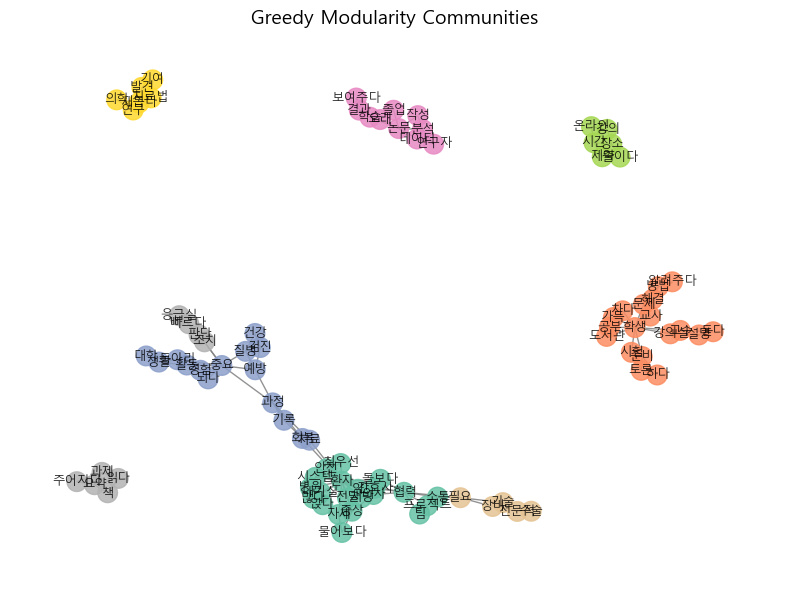

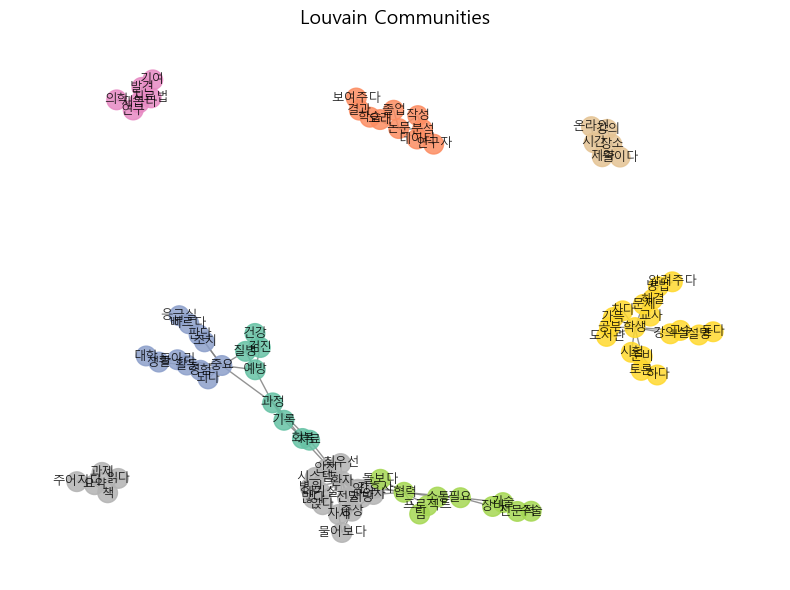

In [18]:
pos = nx.spring_layout(G_win, seed=123)

draw_token_community_graph(
    G_win,
    pos,
    community_attr="M",
    title="Greedy Modularity Communities"
)

draw_token_community_graph(
    G_win,
    pos,
    community_attr="L",
    title="Louvain Communities"
)


결과를 텍스트로도 살펴보겠습니다. 

In [19]:
print("커뮤니티 탐지 결과: ", "\n")
for i, s in enumerate(modularity_com):
    print(f'{i+1} 번째 커뮤니티:')
    print(set(s))
print("\n\n\n", "커뮤니티 탐지 개수: ", len(modularity_com))

커뮤니티 탐지 결과:  

1 번째 커뮤니티:
{'대기실', '안전', '자세', '간호사', '많다', '전달', '프로젝트', '약', '병원', '시스템', '협력', '처방', '물어보다', '소통', '최우선', '증상', '돌보다', '앉다', '팀', '의사', '환자'}
2 번째 커뮤니티:
{'교수', '도서관', '시험', '알려주다', '토론', '공부', '해결', '듣다', '차다', '학생', '하다', '교사', '준비', '방법', '강의실', '설명', '가득', '문제'}
3 번째 커뮤니티:
{'생활', '중요', '대학', '기록', '경험', '예방', '건강', '회복', '되다', '과정', '동아리', '활동', '질병', '치료', '검진'}
4 번째 커뮤니티:
{'결과', '오래', '졸업', '작성', '연구자', '논문', '보여주다', '분석', '학습', '데이터'}
5 번째 커뮤니티:
{'줄이다', '제약', '온라인', '시간', '강의', '장소'}
6 번째 커뮤니티:
{'새롭다', '치료법', '기여', '의학', '발견', '연구'}
7 번째 커뮤니티:
{'장비', '수술', '기술', '필요', '전문적'}
8 번째 커뮤니티:
{'주어지다', '과제', '책', '읽다', '요약'}
9 번째 커뮤니티:
{'빠르다', '판단', '응급실', '조치'}



 커뮤니티 탐지 개수:  9


In [20]:
print("커뮤니티 탐지 결과: ", "\n")
for i, s in enumerate(louvain_com):
    print(f'{i+1} 번째 커뮤니티:')
    print(set(s))
print("\n\n\n", "커뮤니티 탐지 개수: ", len(louvain_com))

커뮤니티 탐지 결과:  

1 번째 커뮤니티:
{'기록', '예방', '치료', '회복', '과정', '질병', '건강', '검진'}
2 번째 커뮤니티:
{'결과', '오래', '졸업', '작성', '연구자', '논문', '보여주다', '분석', '학습', '데이터'}
3 번째 커뮤니티:
{'생활', '중요', '대학', '경험', '빠르다', '되다', '판단', '동아리', '응급실', '조치', '활동'}
4 번째 커뮤니티:
{'새롭다', '의학', '기여', '치료법', '발견', '연구'}
5 번째 커뮤니티:
{'프로젝트', '협력', '수술', '기술', '필요', '소통', '전문적', '돌보다', '장비', '팀'}
6 번째 커뮤니티:
{'교수', '도서관', '시험', '알려주다', '공부', '해결', '토론', '듣다', '차다', '학생', '하다', '교사', '준비', '방법', '강의실', '설명', '가득', '문제'}
7 번째 커뮤니티:
{'줄이다', '제약', '온라인', '시간', '강의', '장소'}
8 번째 커뮤니티:
{'과제', '책', '주어지다', '읽다', '요약'}
9 번째 커뮤니티:
{'대기실', '안전', '자세', '간호사', '전달', '많다', '약', '시스템', '처방', '물어보다', '병원', '최우선', '증상', '앉다', '의사', '환자'}



 커뮤니티 탐지 개수:  9


어떤가요? 쉬우시죠? 의도적으로 주제를 나눠서 생성한 가상 데이터라, 해석하는 것도 큰 문제가 없으실 것입니다. 다만 실제 데이터를 쓰시면 여러 문제를 마주하실 겁니다. 예를 들어 문서가 아주아주 많으면, 토큰 네트워크가 아주 밀도가 높아집니다. 왠만하면 토큰들이 서로 연결되어 있다는 말이죠. 그럼 유의미한 연결을 식별하기 위해 연결 강도(weight) 등으로 링크를 필터링 해주는 경우도 생깁니다. 예를 들어 근접 출현 100회 이상이 있을 때만 링크를 형성하는 식이죠. 그건 그때그때의 목표와 데이터에 따라 판단하셔야 할 것입니다. 

나아가 시각화에서 흔히 쓰는 방법도 있습니다. 예를 들어 지금은 시각화에서 모든 노드 레이블을 다 붙였는데, '중요' 단어에만 붙이는 방식도 있습니다. 예를 들어 디그리(degree), 즉 링크수가 일정 이상인 노드만 레이블을 붙이는거죠. 

나아가 이렇게 탐지된 커뮤니티 결과를 다른 분석의 출발점으로 쓰는 경우도 있습니다. 예를 들어 특정 커뮤니티를 특정 주제의 벡터 표현 같은거라고 해석하고 그 커뮤니티가 언어 자료에서 차지하는 비중을 분석하는 경우도 있습니다. Rule, A., Cointet, J. P., & Bearman, P. S. (2015). Lexical shifts, substantive changes, and continuity in State of the Union discourse, 1790–2014. Proceedings of the National Academy of Sciences, 112(35), 10837-10844. 이런 논문이 그런 방법을 활용합니다. 

제가 길게 설명드렸지만, 사실 여러 창의적 활용을 위한 재료만 준비해드린 셈입니다. 이 이후의 활용은 여러분 몫입니다. 즐거운 탐구 되시기 바랍니다!!^^